# BESS SOH Degradation Model (v11) — Annotated, Runnable Notebook

This notebook is your `bess_model_v11_soc_dod.py` script, split into the same
sections the script itself uses, with a plain-language, line-by-line
explanation **before each block of code**, and the **real printed output +
charts** produced by actually running it (see the "RUN THE MODEL" section at
the bottom).

**How to use this in Google Colab:**
1. Run every cell from top to bottom (Runtime → Run all).
2. Before the final "RUN THE MODEL" section, upload your own
   `OEM_Baseline_Python_Readable.xlsx` and `Field_Data_ModelReady.xlsx` to the
   Colab file browser (left sidebar → Files → Upload). This notebook already
   includes a small stand-in OEM workbook so it runs even without your file —
   swap it out for your real one for production use (see the note in that
   section).
3. All function/parameter definitions are unchanged from your script — only
   the packaging into cells + the explanatory text is new.


## 0. Docstring & imports

This is the script's header docstring (what the model is, why v3 exists,
what literature it's grounded in, what files it expects) followed by all
library imports:

- `numpy` / `pandas` — numeric arrays and the day-by-day data tables.
- `scipy.optimize.minimize` — the L-BFGS-B optimizer used twice in
  `calibrate()` to fit the physics parameters.
- `matplotlib` (`Agg` backend, i.e. no interactive window — just save PNGs).
- `openpyxl` — reads/writes the `.xlsx` files directly (used for the OEM
  input, and for building the multi-sheet results workbook).
- `warnings.filterwarnings("ignore")` — suppresses noisy library warnings so
  the printed physics diagnostics stay readable.


In [1]:
"""
bess_model_v11_soc_dod.py — BESS SOH Degradation Model v11
Step-aware, OEM-anchored, physics-informed semi-empirical model.

Why v3 exists:
- v2 tried to fit sudden BMS/SOH step drops as real continuous degradation.
- That forced cycle degradation to spike and made forecast reach 65% too early.
- v3 separates smooth aging from step/recalibration events for calibration.
- Forecast still starts from the latest observed SOH by default.

Inputs expected in current folder:
- OEM_Baseline_Python_Readable.xlsx
- Field_Data_ModelReady.xlsx

No interactive inputs. Forecast scenario is derived automatically from the provided field data.

Literature basis encoded in the model:
- Wang et al. (2011), J. Power Sources: LFP capacity fade can be represented with a
  power-law dependence on time/charge throughput and Arrhenius temperature scaling.
- Schimpe et al. (2018), J. Electrochemical Society: LFP/graphite degradation should
  be decomposed into calendar and cycle-aging contributions with temperature-dependent mechanisms.
- Birkl et al. (2017), J. Power Sources: SOH changes can reflect different degradation
  modes and diagnostic/estimation effects, so abrupt SOH steps should not automatically
  be forced into smooth electrochemical aging.
- Extreme-value / peaks-over-threshold modelling: future hot spikes are represented
  with a data-fitted high-temperature residual tail rather than an always-on arbitrary
  Gumbel offset.

Outputs:
- bess_soh_results_v8.png
- bess_diagnostics_v8.png
- bess_model_results_v8.xlsx
"""

import os
import sys
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from openpyxl import Workbook, load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings("ignore")

## 1. Version + user settings — every tunable constant in one place

This block is the model's **control panel**. Nothing here is fit from data —
these are engineering choices/knobs. Key groups, in order of appearance:

- **`MODEL_VERSION`, `VERBOSE`** — a version tag printed at the top of every
  run, and a flag that turns on extra `print()` diagnostics during loading.
- **Physical constants**: `R` (gas constant), `T_REF_C = 35°C` (the OEM's
  reference temperature — all Arrhenius temperature scaling is relative to
  this), `OEM_DOD_REF = 100%` (OEM curve is defined as a full-depth-of-discharge
  reference), `DEFAULT_FIELD_DOD = 95%` (fallback if a field file has no DoD
  column).
- **SOC zones for the v11 U-shaped calendar factor**: `SOC_LOW_LIMIT=45`,
  `SOC_REWARD_CENTER=60`, `SOC_HIGH_LIMIT=75` — below 45% and above 75% storage
  SOC gets a calendar-aging penalty; the "sweet spot" is centered at 60%.
- **Stress thresholds**: `T_LIMIT_C=40` (hot-spike threshold),
  `T_COLD_C=10` (cold threshold), `EOL_SOH=65` (the % SOH the forecast is run
  out to).
- **Step-detection tuning** (`STEP_THRESHOLD_PP`, `STEP_MIN_DROP_PP`,
  `STEP_ROBUST_SIGMA`, `STEP_WINDOW_DAYS`, `STEP_WINDOW_WEIGHT`,
  `STEP_ARTIFACT_RATIO`, `STEP_STRESS_Z_LIMIT`) — controls used later by
  `prepare_calibration_target()` to decide what counts as a "BMS
  recalibration jump" vs. real capacity loss.
- **`FORECAST_START_DEFAULT = "model"`** — the forecast continues from the
  model's own smoothed SOH estimate at the end of the field data, not the
  noisy raw last data point (see `forecast()` later).
- **Literature-based priors**: `ALPHA_PRIOR=0.50`, `BETA_PRIOR=0.552`,
  `EA_CAL_PRIOR`, `EA_CYC_PRIOR` and their `_SIGMA` widths — these gently pull
  the fitted exponents/activation energies toward published LFP-battery
  values (see the `LITERATURE_BASIS` list right below, which is later written
  out to the Excel workbook, complete with source URLs).
- **`W_FIELD`, `W_OEM`, `W_REG`, `W_PHYS`, `W_SHARE`, `W_CYCLE_SHARE`,
  `W_ALPHA_PRIOR`, `W_BETA_PRIOR`, `W_EA_PRIOR`** — the relative weights used
  inside `objective_stage2()` to balance "fit the field data" vs "stay near
  OEM" vs "stay physically plausible" vs "respect the literature priors."
- **Forecast temperature-tail settings** (`TEMP_TAIL_QUANTILE=0.90`, etc.) —
  used by `_fit_tail_model()` to let future heat spikes exceed the historical
  maximum, without forcing a spike every single day.
- **`PARAM_NAMES`, `PARAM_INIT`, `PARAM_LOWER`, `PARAM_UPPER`, `PARAM_SIGMA`**
  — the 13 physics parameters the optimizer will fit, their starting guesses,
  hard bounds, and the "how far is a big move" scale used for regularization.
- **`theta_to_dict()` / `clean_params()`** — tiny helpers converting between a
  flat 13-number array (what `scipy.optimize` needs) and a named dictionary
  (what the physics functions use for readability), and stripping the
  underscore-prefixed diagnostic entries (`_rmse_raw`, etc.) that get
  attached to the params dict after calibration.


In [2]:
MODEL_VERSION = "v11_soc_dod_u_shape_physics"
VERBOSE = True

# Fixed physical/engineering constants
R          = 8.314
T_REF_C    = 35.0
T_REF_K    = T_REF_C + 273.15

# V11 SOC/DoD references
# - OEM baseline is treated as the full-cycle reference: 100% DoD.
# - Field DoD is read from Avg_DoD_pct when available; otherwise 95% is used as fallback.
# - DOD is retained as a legacy alias so old workbook/scenario logic does not break,
#   but new physics uses row-wise DOD_actual wherever possible.
OEM_DOD_REF        = 1.00
DEFAULT_FIELD_DOD  = 0.95
DOD                = DEFAULT_FIELD_DOD  # legacy fallback only
C_REF              = OEM_DOD_REF / 4.0

SOC_LOW_LIMIT      = 45.0
SOC_REWARD_CENTER  = 60.0
SOC_HIGH_LIMIT     = 75.0
SOC_REF            = SOC_HIGH_LIMIT

T_LIMIT_C  = 40.0
T_COLD_C   = 10.0
EOL_SOH    = 65.0

# Step/recalibration handling
# v4 note:
# - STEP_THRESHOLD_PP = None means the threshold is estimated robustly from the
#   local one-day SOH-drop residuals instead of being anchored to one dataset.
# - STEP_MIN_DROP_PP prevents tiny daily noise from being classified as a BMS step.
# - Detected steps are then classified categorically as estimator_artifact or
#   physical_candidate. We do NOT blend them using a fixed 0.5 recovery fraction.
STEP_THRESHOLD_PP = None
STEP_MIN_DROP_PP = 0.05
STEP_ROBUST_SIGMA = 8.0
STEP_WINDOW_DAYS  = 3
STEP_WINDOW_WEIGHT = 0.20
STEP_ARTIFACT_RATIO = 5.0
STEP_STRESS_Z_LIMIT = 4.0

# Forecast start policy
# Defaulting to "model" avoids anchoring future physics forecasts to raw SOH values
# that may include BMS-estimator discontinuities. v6 does not ask for terminal
# input and does not require Scenario_Input.xlsx.
FORECAST_START_DEFAULT = "model"

# Physics-informed priors. These are not fitted to this one dataset; they are weak
# regularisation anchors used when the field data cannot uniquely identify a parameter.
# Shape priors:
# - Calendar SEI-dominated fade is commonly represented with a square-root
#   time dependence (~t^0.5), but long field data can show exponents above 0.5.
# - Cycle fade in Wang-style LFP models is also represented by a sub-linear
#   power law in accumulated charge/energy throughput.
# These are weak priors, not hard curve forcing.
# Literature-traceable soft priors. These are NOT curve-forcing rules.
# They anchor underdetermined parameters to published LFP/graphite evidence.
# - Attia et al. (2020): t^0.5 SEI/storage-aging dependence is common, but not universal.
# - Wang et al. (2011), summarized by Jin et al. (2018): graphite-LiFePO4 C/2
#   cycle fade Q_loss = 30330*exp(-31500/(R*T))*Ah^0.552.
# - Yagci et al. (2025): large-format stationary-storage LFP cells showed a
#   global activation energy of 37.3 kJ/mol across protocols.
ALPHA_PRIOR = 0.50
ALPHA_PRIOR_SIGMA = 0.15
BETA_PRIOR = 0.552
BETA_PRIOR_SIGMA = 0.08
EA_CAL_PRIOR = 37300.0
EA_CYC_PRIOR = 31500.0
EA_CAL_PRIOR_SIGMA = 12000.0
EA_CYC_PRIOR_SIGMA = 5000.0
W_ALPHA_PRIOR = 0.30
W_BETA_PRIOR = 0.45
W_EA_PRIOR = 0.10

LITERATURE_BASIS = [
    {
        "topic": "Cycle power-law + Arrhenius temperature",
        "equation_or_value": "Q_loss = B * exp(-Ea/(R*T)) * Ah^z",
        "model_use": "Cycle aging term uses Delta(EFC_cum^beta) and Arrhenius f_T_cyc",
        "paper": "Wang et al., Cycle-life model for graphite-LiFePO4 cells, Journal of Power Sources, 2011",
        "source_url": "https://ui.adsabs.harvard.edu/abs/2011JPS...196.3942W",
    },
    {
        "topic": "Graphite-LFP C/2 fitted cycle parameters",
        "equation_or_value": "C/2: Q_loss = 30330 * exp(-31500/(R*T)) * Ah^0.552",
        "model_use": "beta prior = 0.552; Ea_cyc prior = 31500 J/mol",
        "paper": "Jin et al., Applicability of available Li-ion battery degradation models, Control Engineering Practice, 2018",
        "source_url": "https://www.osti.gov/servlets/purl/1538186",
    },
    {
        "topic": "Calendar/cycle separation for LFP/graphite",
        "equation_or_value": "One calendar and several cycle aging effects modeled separately",
        "model_use": "SOH loss is calendar loss + cycle loss, not a single black-box curve",
        "paper": "Schimpe et al., Comprehensive modeling of temperature-dependent degradation mechanisms in lithium iron phosphate batteries, JES, 2018",
        "source_url": "https://www.osti.gov/pages/biblio/1421782",
    },
    {
        "topic": "SEI/storage t^0.5 caveat",
        "equation_or_value": "t^0.5 is common for SEI/storage aging but not universally sufficient",
        "model_use": "alpha prior = 0.50 is soft; not a hard law",
        "paper": "Attia, Chueh & Harris, Revisiting the t0.5 Dependence of SEI Growth, JES, 2020",
        "source_url": "https://www.osti.gov/pages/biblio/1635182",
    },
    {
        "topic": "Large-format stationary-storage LFP activation energy",
        "equation_or_value": "global activation energy = 37.3 kJ/mol",
        "model_use": "Ea_cal soft prior = 37300 J/mol",
        "paper": "Yagci et al., Degradation modes of large-format stationary-storage LFP-based lithium-ion cells, Journal of Energy Storage, 2025",
        "source_url": "https://www.sciencedirect.com/science/article/pii/S2352152X25014872",
    },
]

# Scenario/uncertainty analysis settings. These are engineering sensitivity runs,
# not literature claims and not hard constraints on the forecast curve.
SCENARIO_FORECAST_YEARS = 30
PARAM_ENSEMBLE_N = 60
PARAM_ENSEMBLE_SEED = 2027
ENABLE_ML_RESIDUAL_DIAGNOSTIC = True

# v10 guarded residual-correction controls.
# This is OFF by default because the physics/OEM model should remain the main forecast.
# Turn it on only after the residual model beats the zero-residual baseline on chronological validation.
ENABLE_ML_RESIDUAL_FORECAST_CORRECTION = False
ML_RESIDUAL_MAX_ABS_PP = 1.5
ML_RESIDUAL_MIN_TEST_IMPROVEMENT_PP = 0.10
ML_RESIDUAL_DECAY_YEARS = 3.0
# HistGradientBoostingRegressor supports monotonic constraints in sklearn, but on some
# Windows/Anaconda/OpenMP setups it can be slow or hang. Keep False for a robust
# student/internship script; set True only after testing your local environment.
USE_MONOTONIC_HIST_GB_FOR_RESIDUAL = True
# Openpyxl append of many extra sheets can be slow on some laptops. The core workbook
# and all plots are still produced when this is False. Turn True if you want extra audit sheets.
ENABLE_EXTENDED_EXCEL_APPEND = False

# Calibration weights
W_FIELD = 1.00       # fit smooth step-adjusted field target
W_OEM   = 0.30       # keep reference-condition behavior close to OEM baseline
W_REG   = 0.03       # prevent unrealistic parameter drift
W_PHYS  = 0.20       # monotonic/positive/physical penalties
W_SHARE = 0.50       # discourages calendar aging from collapsing to zero

# Cycle-aging guardrail. If the plant is cycling every day, the optimizer should
# not be allowed to silently make cycle aging exactly zero just to reconcile an
# optimistic synthetic field SOH curve with the OEM anchor. The target minimum
# scales down when mean EFC/day is small, so low-cycling assets are not forced
# to be cycle-dominated.
MIN_CYCLE_SHARE_AT_DAILY_EFC = 0.20
W_CYCLE_SHARE = 0.70
CYCLE_COLLAPSE_WARN_SHARE = 0.05

# Forecast temperature model. v6 added a positive Gumbel spike every forecast day.
# v7 replaces that with an empirical peaks-over-threshold tail fitted to the
# provided field T_max - T_avg residuals. This keeps the possibility of future
# spikes above the historical max without hard-capping forecasts at 40°C.
FORECAST_RANDOM_SEED = 42
TEMP_TAIL_QUANTILE = 0.90
TEMP_TAIL_MIN_EXCESS_SCALE_C = 0.25
TEMP_ABSOLUTE_SENSOR_CAP_C = 65.0
TAVG_ABSOLUTE_MIN_C = -20.0
TAVG_ABSOLUTE_MAX_C = 58.0
TMIN_ABSOLUTE_MIN_C = -25.0

# Parameter order:
# A_cal, A_cyc, Ea_cal, Ea_cyc, alpha, beta,
# k_SOC_high, k_SOC_reward, k_SOC_low, gamma_DoD, k_C, k_Tmax, k_Tmin
PARAM_NAMES = [
    "A_cal", "A_cyc", "Ea_cal", "Ea_cyc", "alpha", "beta",
    "k_SOC_high", "k_SOC_reward", "k_SOC_low", "gamma_DoD",
    "k_C", "k_Tmax", "k_Tmin",
]

# v5/v11 cumulative power-law scales.
# A_cal multiplies Δ(t^alpha), so its unit is pp / day^alpha.
# A_cyc multiplies Δ(EFC^beta), so its unit is pp / EFC^beta.
# V11 replaces the single generic SOC multiplier with a calendar-only U-shaped SOC map
# and adds an explicit DoD stress factor to the cycle-aging term.
PARAM_INIT  = np.array([
    0.18, 0.08, EA_CAL_PRIOR, EA_CYC_PRIOR, ALPHA_PRIOR, BETA_PRIOR,
    0.60, 0.18, 0.45, 1.00,
    0.35, 0.010, 0.005,
])
PARAM_LOWER = np.array([
    0.0000, 0.0000, 20000.0, 15000.0, 0.35, 0.35,
    0.00, 0.00, 0.00, 0.30,
    0.00, 0.000, 0.000,
])
# alpha upper is kept below 1.0 so the normal pre-knee aging rate slows with age.
# gamma_DoD is bounded to keep the DoD multiplier physically reasonable with synthetic data.
PARAM_UPPER = np.array([
    2.0000, 2.0000, 80000.0, 60000.0, 0.85, 0.95,
    2.00, 0.40, 2.00, 2.00,
    1.25, 0.250, 0.100,
])
PARAM_SIGMA = np.array([
    0.30, 0.30, EA_CAL_PRIOR_SIGMA, EA_CYC_PRIOR_SIGMA, 0.15, 0.20,
    0.60, 0.15, 0.60, 0.35,
    0.50, 0.100, 0.050,
])

def theta_to_dict(theta):
    return dict(zip(PARAM_NAMES, theta))

def clean_params(params):
    return {k: v for k, v in params.items() if not k.startswith("_")}

## 2. Column schema — making the script tolerant of different spreadsheet headers

- **`FIELD_COL_ALIASES`** is a dictionary mapping each *canonical* column
  name the model's functions expect (e.g. `T_avg_C`) to a list of
  *acceptable alternative* header names it might find in your Excel file
  (e.g. `Avg_Temp_C`, `avg_temp_c`). This is exactly what let the script run
  on your files without you renaming any columns — your files use
  `Avg_Temp_C` / `Max_Temp_C` / `Min_Temp_C`, and the alias map silently
  mapped them.
- **`FIELD_REQUIRED`** — the list of columns that MUST exist (after alias
  resolution) or the script raises a clear `KeyError` naming what's missing.
- **`_resolve_columns()`** — loops over the alias map, and for every
  canonical name not already present, looks for the first matching alias in
  your dataframe and renames it. It prints exactly which renames it made.


In [3]:
FIELD_COL_ALIASES = {
    "Date":                  ["Date", "date", "DATE"],
    "SOH_pct":               ["SOH_pct", "SOH_Pct", "SOH", "soh_pct"],
    "Avg_SOC_pct":           ["Avg_SOC_pct", "Avg_SOC", "SOC_avg_pct", "SOC_pct", "avg_soc_pct"],
    "Avg_DoD_pct":           ["Avg_DoD_pct", "Avg_DOD_pct", "Avg_DoD", "DOD_pct", "DoD_pct", "avg_dod_pct"],
    "EFC_per_day":           ["EFC_per_day", "efc_per_day"],
    "Cycles_per_day":        ["Cycles_per_day", "cycles_per_day", "Cycles/day", "Cycles"],
    "Charge_Duration_hr":    ["Charge_Duration_hr", "Charge_Duration", "Charge_hr"],
    "Discharge_Duration_hr": ["Discharge_Duration_hr", "Discharge_Duration", "Discharge_hr"],
    "T_avg_C":               ["T_avg_C", "Avg_Temp_C", "avg_temp_c", "T_Avg_C"],
    "T_max_C":               ["T_max_C", "Max_Temp_C", "max_temp_c", "T_Max_C"],
    "T_min_C":               ["T_min_C", "Min_Temp_C", "min_temp_c", "T_Min_C"],
    "DCIR_mOhm":             ["DCIR_mOhm", "DCIR"],
    "OEM_SOH_at_same_age_pct":["OEM_SOH_at_same_age_pct", "OEM_SOH_pct", "OEM_SOH"],
}
FIELD_REQUIRED = ["Date", "SOH_pct", "Avg_SOC_pct",
                  "Charge_Duration_hr", "Discharge_Duration_hr",
                  "T_avg_C", "T_max_C", "T_min_C"]

def _resolve_columns(df: pd.DataFrame, alias_map: dict, verbose: bool = True) -> pd.DataFrame:
    rename_map = {}
    for canonical, aliases in alias_map.items():
        if canonical in df.columns:
            continue
        for alias in aliases:
            if alias in df.columns:
                rename_map[alias] = canonical
                break
    if rename_map and verbose:
        print(f"  [column alias] internal rename only: {rename_map}")
    return df.rename(columns=rename_map)

## 3. Data loading — reading the OEM curve and the field data, and building the temperature model

Four functions here, in the order `main()` calls them:

1. **`load_oem_data(path)`** — reads the `OEM_Baseline` sheet, requires
   `Day, OEM_SOH_pct, OEM_Avg_SOC_pct, OEM_Avg_Temp_C, OEM_Charge_hr,
   OEM_Discharge_hr, OEM_Cycles_per_day`. It also reads an optional
   `OEM_Avg_DoD_pct` column (falls back to 100% if absent), then derives
   `EFC_per_day`, `C_charge_op`, `C_discharge_op` from those, and — important
   side effect — **updates the global `C_REF`** (the reference C-rate every
   field day's C-rate is compared against later).
2. **`expand_oem_to_daily(oem_df)`** — the OEM curve usually has only a
   handful of annual points. `np.interp()` linearly fills in every day
   between them so calibration can run day-by-day.
3. **`load_field_data(path)`** — reads `Sheet1`, resolves column aliases,
   computes `DOD_actual`, `C_charge_op`, `C_discharge_op`, fills in whichever
   of `EFC_per_day` / `Cycles_per_day` is missing from the other, then calls
   `prepare_calibration_target()` (next section) to build the step-aware
   smooth SOH target, and `build_monthly_temperature_model()` to fingerprint
   the site's seasonal temperature pattern for later forecasting.
4. **`build_monthly_temperature_model(df)`** — for each calendar month,
   stores the mean `T_avg/T_max/T_min`, plus (via the small internal helpers
   `_safe_numeric_array`, `_fit_tail_model`, `_sample_tail_residual`) an
   **empirical residual distribution** for `T_avg` and a **statistically
   fitted "peaks-over-threshold" tail** for how far `T_max` can spike above
   `T_avg` on a hot day. This tail model is what lets the 30-year forecast
   simulate future heatwaves *hotter than any day ever observed*, without
   hard-coding an arbitrary spike size.


In [4]:
def load_oem_data(path: str) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name="OEM_Baseline")
    df.columns = df.columns.str.strip()

    required = ["Day", "OEM_SOH_pct", "OEM_Avg_SOC_pct", "OEM_Avg_Temp_C",
                "OEM_Charge_hr", "OEM_Discharge_hr", "OEM_Cycles_per_day"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"[load_oem_data] Missing OEM columns: {missing}\nAvailable: {list(df.columns)}")

    # V11 patch: read OEM DoD from workbook when available.
    # If OEM_Avg_DoD_pct is changed in the OEM_Baseline sheet, the model now uses
    # that value for OEM EFC/day, OEM C-rate, the OEM reference scenario, and audits.
    # If the column is missing/blank, fall back to OEM_DOD_REF = 100%.
    if "OEM_Avg_DoD_pct" in df.columns:
        df["Avg_DoD_pct"] = pd.to_numeric(df["OEM_Avg_DoD_pct"], errors="coerce").fillna(OEM_DOD_REF * 100.0)
        dod_source = "OEM_Avg_DoD_pct column"
    else:
        df["Avg_DoD_pct"] = OEM_DOD_REF * 100.0
        dod_source = "code fallback OEM_DOD_REF"

    df["Avg_DoD_pct"]     = df["Avg_DoD_pct"].clip(lower=1.0, upper=100.0)
    df["DOD_actual"]      = df["Avg_DoD_pct"] / 100.0
    df["Cycles_per_day"]  = df["OEM_Cycles_per_day"]
    df["EFC_per_day"]     = df["OEM_Cycles_per_day"] * df["DOD_actual"]
    df["C_charge_op"]     = df["DOD_actual"] / df["OEM_Charge_hr"]
    df["C_discharge_op"]  = df["DOD_actual"] / df["OEM_Discharge_hr"]
    df["T_avg_C"]         = df["OEM_Avg_Temp_C"]
    df["T_max_C"]         = df["OEM_Avg_Temp_C"]
    df["T_min_C"]         = df["OEM_Avg_Temp_C"]
    df["Avg_SOC_pct"]     = df["OEM_Avg_SOC_pct"]
    df["dt_days"]         = 1.0

    # Update the global C-rate reference from the OEM sheet.
    # Example: 100% DoD / 4 h = 0.25C; 95% DoD / 4 h = 0.2375C.
    global C_REF
    C_REF = float(np.nanmean([df["C_charge_op"].mean(), df["C_discharge_op"].mean()]))

    print(f"[load_oem_data] {len(df)} OEM rows | SOH {df['OEM_SOH_pct'].min():.2f}–{df['OEM_SOH_pct'].max():.2f}%")
    print(f"[load_oem_data] OEM DoD source: {dod_source} | mean OEM DoD={df['Avg_DoD_pct'].mean():.2f}% | C_REF={C_REF:.4f}C")
    return df

def expand_oem_to_daily(oem_df: pd.DataFrame) -> pd.DataFrame:
    """
    Important v3 fix:
    The OEM baseline is usually annual/sparse, but the model operates daily.
    v1/v2 simulated OEM annual rows directly, which made cycle aging inconsistent.
    Here we interpolate OEM baseline and reference operating conditions to daily rows.
    """
    max_day = int(np.nanmax(oem_df["Day"].values))
    days = np.arange(0, max_day + 1)

    daily = pd.DataFrame({"Day": days})
    interp_cols = ["OEM_SOH_pct", "OEM_Avg_SOC_pct", "OEM_Avg_Temp_C",
                   "OEM_Charge_hr", "OEM_Discharge_hr", "OEM_Cycles_per_day"]
    for col in interp_cols:
        daily[col] = np.interp(days, oem_df["Day"].values, oem_df[col].values)

    # V11 patch: interpolate the OEM DoD loaded from the workbook.
    # This lets future edits to OEM_Avg_DoD_pct, e.g. 100 -> 95, flow into
    # the daily OEM calibration rows without changing code again.
    if "Avg_DoD_pct" in oem_df.columns:
        daily["Avg_DoD_pct"] = np.interp(days, oem_df["Day"].values, oem_df["Avg_DoD_pct"].values)
    elif "OEM_Avg_DoD_pct" in oem_df.columns:
        daily["Avg_DoD_pct"] = np.interp(days, oem_df["Day"].values, oem_df["OEM_Avg_DoD_pct"].values)
    else:
        daily["Avg_DoD_pct"] = OEM_DOD_REF * 100.0

    daily["Avg_DoD_pct"]    = pd.to_numeric(daily["Avg_DoD_pct"], errors="coerce").fillna(OEM_DOD_REF * 100.0).clip(lower=1.0, upper=100.0)
    daily["DOD_actual"]     = daily["Avg_DoD_pct"] / 100.0
    daily["Cycles_per_day"] = daily["OEM_Cycles_per_day"]
    daily["EFC_per_day"]    = daily["OEM_Cycles_per_day"] * daily["DOD_actual"]
    daily["C_charge_op"]    = daily["DOD_actual"] / daily["OEM_Charge_hr"]
    daily["C_discharge_op"] = daily["DOD_actual"] / daily["OEM_Discharge_hr"]
    daily["T_avg_C"]        = daily["OEM_Avg_Temp_C"]
    daily["T_max_C"]        = daily["OEM_Avg_Temp_C"]
    daily["T_min_C"]        = daily["OEM_Avg_Temp_C"]
    daily["Avg_SOC_pct"]    = daily["OEM_Avg_SOC_pct"]
    daily["dt_days"]        = 1.0

    print(f"[expand_oem_to_daily] OEM expanded to {len(daily)} daily rows for calibration.")
    return daily

def load_field_data(path: str):
    df = pd.read_excel(path, sheet_name="Sheet1")
    df.columns = df.columns.str.strip()

    if VERBOSE:
        print(f"[load_field_data] Excel columns: {list(df.columns)}")

    df = _resolve_columns(df, FIELD_COL_ALIASES, verbose=VERBOSE)

    has_efc = "EFC_per_day" in df.columns
    has_cycles = "Cycles_per_day" in df.columns

    missing = [c for c in FIELD_REQUIRED if c not in df.columns]
    if not has_efc and not has_cycles:
        missing.append("EFC_per_day or Cycles_per_day")
    if missing:
        raise KeyError(
            f"[load_field_data] Missing columns: {missing}\n"
            f"Available: {list(df.columns)}\n"
            f"Required: {FIELD_REQUIRED} + EFC_per_day or Cycles_per_day"
        )

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["Month"] = df["Date"].dt.month

    # V11: use actual daily DoD if supplied. If the old V10 workbook does not
    # contain Avg_DoD_pct, fall back to the previous 95% assumption so the same
    # Excel files still run without column-name changes.
    if "Avg_DoD_pct" not in df.columns:
        df["Avg_DoD_pct"] = DEFAULT_FIELD_DOD * 100.0
    df["Avg_DoD_pct"] = pd.to_numeric(df["Avg_DoD_pct"], errors="coerce").fillna(DEFAULT_FIELD_DOD * 100.0)
    df["Avg_DoD_pct"] = df["Avg_DoD_pct"].clip(lower=1.0, upper=100.0)
    df["DOD_actual"] = df["Avg_DoD_pct"] / 100.0

    df["C_charge_op"] = df["DOD_actual"] / df["Charge_Duration_hr"]
    df["C_discharge_op"] = df["DOD_actual"] / df["Discharge_Duration_hr"]

    if not has_efc:
        df["EFC_per_day"] = df["Cycles_per_day"] * df["DOD_actual"]
    if not has_cycles:
        df["Cycles_per_day"] = df["EFC_per_day"] / df["DOD_actual"].replace(0, np.nan)
        df["Cycles_per_day"] = df["Cycles_per_day"].fillna(0.0)

    # Create step-aware calibration target
    df = prepare_calibration_target(df, threshold=STEP_THRESHOLD_PP, window=STEP_WINDOW_DAYS)

    monthly_fp = build_monthly_temperature_model(df)

    hot = int((df["T_max_C"] > T_LIMIT_C).sum())
    print(f"[load_field_data] {len(df)} rows | raw SOH {df['SOH_pct'].min():.2f}–{df['SOH_pct'].max():.2f}% | hot days={hot}")
    print(f"[load_field_data] Final raw SOH={df['SOH_pct'].iloc[-1]:.3f}% | final smooth calibration target={df['SOH_calib_target_pct'].iloc[-1]:.3f}%")
    return df, monthly_fp


def _safe_numeric_array(values, fallback=0.0):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.asarray([fallback], dtype=float)
    return arr


def _fit_tail_model(residuals, q=TEMP_TAIL_QUANTILE):
    """
    Fit a simple peaks-over-threshold tail model to a residual distribution.

    We use an exponential excess model above a high empirical threshold. This is
    the xi=0 special case of a Generalized Pareto excess model and is much more
    stable than fitting a full 3-parameter extreme-value distribution from only
    ~3 years of daily field data.

    Returned fields:
    - body: residuals at/below threshold, sampled on normal days
    - threshold: empirical high threshold
    - p_tail: historical probability of exceeding threshold
    - excess_scale: mean excess above threshold, used for future rare spikes
    """
    r = _safe_numeric_array(residuals, fallback=0.0)
    threshold = float(np.quantile(r, q))
    body = r[r <= threshold]
    if body.size == 0:
        body = r
    exceed = r[r > threshold] - threshold
    p_tail = float(exceed.size / max(r.size, 1))
    if exceed.size > 0:
        excess_scale = float(max(np.mean(exceed), TEMP_TAIL_MIN_EXCESS_SCALE_C))
    else:
        # Flat synthetic data can have no excesses. Keep a small non-zero tail
        # scale so future spikes remain possible, but do not add them every day.
        excess_scale = float(TEMP_TAIL_MIN_EXCESS_SCALE_C)
    return {
        "body": np.asarray(body, dtype=float),
        "threshold": threshold,
        "p_tail": p_tail,
        "excess_scale": excess_scale,
    }


def _sample_tail_residual(model, rng):
    """Sample one residual from the empirical body or the fitted high tail."""
    body = model.get("body", np.asarray([0.0]))
    threshold = float(model.get("threshold", 0.0))
    p_tail = float(model.get("p_tail", 0.0))
    excess_scale = float(model.get("excess_scale", TEMP_TAIL_MIN_EXCESS_SCALE_C))
    if rng.random() < p_tail:
        return threshold + rng.exponential(excess_scale)
    return float(rng.choice(body))


def build_monthly_temperature_model(df: pd.DataFrame) -> dict:
    """
    Build a monthly temperature fingerprint plus stochastic residual model.

    The model uses the field data for its seasonal mean structure, but it does
    not assume future Tmax is capped at the historical maximum. Instead, it
    models daily Tmax excursion above Tavg using a peaks-over-threshold residual
    tail. That is the correct compromise for your concern: future spikes remain
    possible, but they are not injected as an arbitrary positive Gumbel offset on
    every single day.
    """
    monthly_fp = {}
    for key, col in [("avg", "T_avg_C"), ("max", "T_max_C"), ("min", "T_min_C")]:
        arr = np.zeros(13)
        for m in range(1, 13):
            sub = df.loc[df["Month"] == m, col]
            arr[m] = float(sub.mean()) if len(sub) else float(df[col].mean())
        monthly_fp[key] = arr

    std_arr = np.zeros(13)
    temp_model = {}
    for m in range(1, 13):
        sub = df.loc[df["Month"] == m].copy()
        if len(sub) == 0:
            sub = df.copy()

        tavg = sub["T_avg_C"].astype(float).values
        tmax = sub["T_max_C"].astype(float).values
        tmin = sub["T_min_C"].astype(float).values

        std_arr[m] = float(np.nanstd(tavg, ddof=1)) if len(tavg) > 1 else 0.5
        tavg_center = float(np.nanmean(tavg))
        tavg_resid = _safe_numeric_array(tavg - tavg_center, fallback=0.0)

        # Use non-negative daily excursions relative to the daily average.
        # This is more transferable than sampling absolute Tmax directly.
        tmax_gap = _safe_numeric_array(np.maximum(tmax - tavg, 0.0), fallback=max(monthly_fp["max"][m] - monthly_fp["avg"][m], 0.0))
        tmin_gap = _safe_numeric_array(np.maximum(tavg - tmin, 0.0), fallback=max(monthly_fp["avg"][m] - monthly_fp["min"][m], 0.0))

        temp_model[m] = {
            "tavg_residuals": tavg_resid,
            "tmax_gap_tail": _fit_tail_model(tmax_gap),
            "tmin_gap_body": tmin_gap,
        }

    monthly_fp["std"] = std_arr
    monthly_fp["temp_model"] = temp_model
    monthly_fp["model_note"] = "monthly mean + empirical residuals + peaks-over-threshold Tmax tail"
    return monthly_fp

## 4. Step / recalibration handling — telling real fade apart from BMS jumps

This is the model's signature idea (see the module docstring: this is *why*
v3 exists). Five functions:

- **`_robust_mad()` / `_robust_z()`** — median-absolute-deviation based
  "robust z-score" helpers, used so that a few extreme days don't distort the
  statistics the way a standard-deviation-based z-score would.
- **`_classify_step_event(df, idx, ...)`** — for a single detected abrupt
  drop, decides: is this an **estimator artifact** (BMS recalibration —
  should be "healed" back into the smooth calibration target) or a
  **physical candidate** (a real capacity-loss event — should be kept)? It
  first checks for manual override columns (`Step_Event_Type`,
  `Step_Is_Artifact`), then falls back to an automatic rule: if the drop is
  ≥5× the locally expected drop **and** there's no supporting DCIR jump, call
  it an artifact; if any stress signal (temperature, EFC, SOC, C-rate, DCIR)
  spikes at the same time, call it a real physical event.
- **`prepare_calibration_target(df, ...)`** — the main entry point:
  1. Computes each day's raw SOH drop and a 31-day rolling-median "locally
     expected" drop.
  2. Flags a day as a step only if its *excess* drop (raw − expected) clears
     an automatically-derived robust threshold.
  3. Classifies every flagged day via `_classify_step_event()`.
  4. Builds `SOH_calib_target_pct` = raw SOH + cumulative "healed" step loss.
  5. Down-weights (`calib_weight`) the few days immediately around any step
     so the optimizer doesn't over-fit to a instrument glitch.
  In your uploaded files, this always printed **"Detected 0 abrupt SOH step
  events"** — expected, since your data is clean synthetic curves. This
  logic exists for messier real-world BMS exports.
- **`detect_soh_steps(field_df, ...)`** — pulls the flagged rows back out
  into a small dataframe purely for the diagnostics plot.


In [5]:
def _robust_mad(values):
    """Median absolute deviation helper; returns a small epsilon when flat."""
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0, 1e-12
    med = float(np.median(arr))
    mad = float(np.median(np.abs(arr - med)))
    return med, max(1.4826 * mad, 1e-12)


def _robust_z(value, reference):
    med, scale = _robust_mad(reference)
    return float((value - med) / scale)


def _classify_step_event(df, idx, detected_step_loss, local_expected_drop):
    """
    Categorical step handling, not fractional blending.

    Returns:
    - recovery_fraction = 1.0 for estimator_artifact: add step back into smooth target.
    - recovery_fraction = 0.0 for physical_candidate: keep step as real capacity loss.

    Optional manual override columns supported in the field Excel:
    - SOH_Event_Type / Step_Event_Type / Event_Type: artifact, bms, recalibration, real, physical, failure
    - Step_Is_Artifact: True/False
    """
    override_cols = ["SOH_Event_Type", "Step_Event_Type", "Event_Type"]
    for col in override_cols:
        if col in df.columns and pd.notna(df.loc[idx, col]):
            label = str(df.loc[idx, col]).strip().lower()
            if label in ("artifact", "bms", "bms_recalibration", "recalibration", "estimator"):
                return 1.0, "manual_estimator_artifact", f"manual {col}={label}"
            if label in ("real", "physical", "failure", "cell_failure", "thermal_event"):
                return 0.0, "manual_physical_candidate", f"manual {col}={label}"

    if "Step_Is_Artifact" in df.columns and pd.notna(df.loc[idx, "Step_Is_Artifact"]):
        is_artifact = bool(df.loc[idx, "Step_Is_Artifact"])
        return (1.0, "manual_estimator_artifact", "manual Step_Is_Artifact=True") if is_artifact else (0.0, "manual_physical_candidate", "manual Step_Is_Artifact=False")

    # A one-day SOH loss many times larger than the local expected smooth loss is
    # normally an estimator/capacity-recalibration discontinuity, not electrochemical
    # degradation that happened in 24 hours.
    magnitude_ratio = detected_step_loss / max(float(local_expected_drop), 1e-6)

    stress_z = []
    stress_details = []
    for col in ["T_max_C", "T_avg_C", "EFC_per_day", "Avg_SOC_pct", "C_charge_op", "C_discharge_op"]:
        if col in df.columns:
            z = _robust_z(df.loc[idx, col], df[col].values)
            stress_z.append(z)
            stress_details.append(f"{col} z={z:.1f}")

    dcir_jump_z = 0.0
    if "DCIR_mOhm" in df.columns:
        dcir_delta = df["DCIR_mOhm"].diff().fillna(0.0).values
        dcir_jump_z = _robust_z(dcir_delta[idx], dcir_delta)
        stress_details.append(f"DCIR jump z={dcir_jump_z:.1f}")

    max_stress_z = max(stress_z) if stress_z else 0.0

    if magnitude_ratio >= STEP_ARTIFACT_RATIO and dcir_jump_z < STEP_STRESS_Z_LIMIT:
        return 1.0, "auto_estimator_artifact", f"step/local={magnitude_ratio:.1f}; " + "; ".join(stress_details)

    if max_stress_z >= STEP_STRESS_Z_LIMIT or dcir_jump_z >= STEP_STRESS_Z_LIMIT:
        return 0.0, "auto_physical_candidate", f"step/local={magnitude_ratio:.1f}; " + "; ".join(stress_details)

    # Abrupt but not stress-supported: safer for smooth physics calibration to treat
    # it as an estimator artifact. Raw SOH is still preserved in the output.
    return 1.0, "auto_estimator_artifact", f"unexplained abrupt step; step/local={magnitude_ratio:.1f}; " + "; ".join(stress_details)


def prepare_calibration_target(df: pd.DataFrame, threshold: float = None, window: int = 3) -> pd.DataFrame:
    """
    Build the smooth calibration target while preserving raw SOH.

    v4 logic:
    1. Estimate normal one-day SOH loss from a rolling local median.
    2. Detect only abrupt excess losses above that local trend.
    3. Classify each abrupt event categorically:
       - estimator_artifact -> add detected excess loss back to calibration target
       - physical_candidate -> keep it in the target as real capacity loss
    4. Downweight windows around detected steps during calibration.

    This avoids a dataset-specific fixed STEP_RECOVERY_FRACTION such as 0.5.
    """
    df = df.copy()
    daily_change = df["SOH_pct"].diff().fillna(0.0)
    raw_drop = np.maximum(-daily_change.values, 0.0)

    local_expected = (
        pd.Series(raw_drop)
        .rolling(31, center=True, min_periods=8)
        .median()
        .bfill()
        .ffill()
        .values
    )
    excess_drop = np.maximum(raw_drop - local_expected, 0.0)

    if threshold is None:
        positive_excess = excess_drop[excess_drop > 0]
        med, robust_scale = _robust_mad(positive_excess)
        auto_threshold = max(STEP_MIN_DROP_PP, med + STEP_ROBUST_SIGMA * robust_scale)
    else:
        auto_threshold = float(threshold)

    detected = excess_drop > auto_threshold
    detected_step_loss = np.where(detected, excess_drop, 0.0)

    recovery_fraction = np.zeros(len(df), dtype=float)
    event_class = np.array(["none"] * len(df), dtype=object)
    event_reason = np.array([""] * len(df), dtype=object)

    idxs = np.where(detected)[0]
    for idx in idxs:
        frac, cls, reason = _classify_step_event(df, idx, detected_step_loss[idx], local_expected[idx])
        recovery_fraction[idx] = frac
        event_class[idx] = cls
        event_reason[idx] = reason

    recovered_step_loss = detected_step_loss * recovery_fraction

    df["Daily_SOH_change_pp"] = daily_change
    df["Expected_smooth_daily_drop_pp"] = local_expected
    df["Detected_step_loss_pp"] = detected_step_loss
    df["Step_recovery_fraction"] = recovery_fraction
    df["Step_event_class"] = event_class
    df["Step_event_reason"] = event_reason
    df["Step_loss_pp"] = recovered_step_loss  # backwards-compatible: amount removed from calibration target
    df["Is_step_event"] = detected
    df["Cumulative_step_loss_pp"] = df["Step_loss_pp"].cumsum()
    df["SOH_calib_target_pct"] = df["SOH_pct"] + df["Cumulative_step_loss_pp"]

    # calibration weights: downweight detected-step windows, regardless of class
    weights = np.ones(len(df))
    for idx in idxs:
        lo = max(0, idx - window)
        hi = min(len(df), idx + window + 1)
        weights[lo:hi] = STEP_WINDOW_WEIGHT
    df["calib_weight"] = weights

    print(f"[prepare_calibration_target] Step threshold used: {auto_threshold:.4f} pp excess/day")
    print(f"[prepare_calibration_target] Detected {len(idxs)} abrupt SOH step events.")
    if len(idxs):
        for idx in idxs:
            print(
                f"  Step day {idx:4d} | {df.loc[idx,'Date'].date()} | "
                f"detected={df.loc[idx,'Detected_step_loss_pp']:.4f} pp | "
                f"recovered={df.loc[idx,'Step_loss_pp']:.4f} pp | "
                f"class={df.loc[idx,'Step_event_class']} | raw SOH={df.loc[idx,'SOH_pct']:.3f}%"
            )
        print(f"  Total detected step loss            : {df['Detected_step_loss_pp'].sum():.3f} pp")
        print(f"  Total recovered into smooth target  : {df['Step_loss_pp'].sum():.3f} pp")
    return df

def detect_soh_steps(field_df: pd.DataFrame, threshold: float = STEP_THRESHOLD_PP) -> pd.DataFrame:
    base_cols = ["Date", "SOH_pct", "Detected_step_loss_pp", "Step_loss_pp",
                 "Step_recovery_fraction", "Step_event_class", "Step_event_reason"]
    cols = [c for c in base_cols if c in field_df.columns]
    events = field_df.loc[field_df["Is_step_event"], cols].copy()
    events["Day_idx"] = events.index
    events = events.reset_index(drop=True)
    print(f"[detect_soh_steps] {len(events)} step events retained for diagnostics.")
    return events

## 5. Scenario input — no manual file needed

- **`load_scenario(field_path, field_df)`** — this is the "v11 no-prompt"
  design: instead of asking you to fill in a `Scenario_Input.xlsx` with
  assumed future SOC/DoD/cycling, it simply **averages your own field data's
  history** (`Avg_SOC_pct`, `Avg_DoD_pct`, `Cycles_per_day`,
  `Charge_Duration_hr`, `Discharge_Duration_hr`) and uses that as the
  forward-looking operating assumption. `forecast_start_mode` is copied from
  the global default (`"model"`).


In [6]:
def load_scenario(field_path: str, field_df: pd.DataFrame) -> dict:
    """
    V11 no-prompt forecast scenario.

    The forecast operating scenario is derived only from the uploaded field data.
    It keeps the same workbook names/sheet expectations as V11, while adding
    Avg_DoD_pct so the forecast uses actual DoD instead of the old fixed 95% DoD.
    """
    scenario = {
        "Avg_SOC_pct":           float(field_df["Avg_SOC_pct"].mean()),
        "Avg_DoD_pct":           float(field_df.get("Avg_DoD_pct", pd.Series([DEFAULT_FIELD_DOD * 100.0])).mean()),
        "Cycles_per_day":        float(field_df["Cycles_per_day"].mean()),
        "Charge_Duration_hr":    float(field_df["Charge_Duration_hr"].mean()),
        "Discharge_Duration_hr": float(field_df["Discharge_Duration_hr"].mean()),
        "Temp_offset_C":         0.0,
        "forecast_start_mode":   FORECAST_START_DEFAULT,
        "temperature_forecast_model": "monthly_empirical_residuals_plus_POT_Tmax_tail",
        "scenario_source":       "auto_from_field_data_mean",
    }
    print("[load_scenario] v11 no-prompt mode: using field-data averages including Avg_DoD_pct.")
    return scenario

## 6. Model equations — the actual physics

This is the heart of the model. Five functions, building up from small
pieces to the full daily SOH update:

- **`_get_dod_actual_array()`** — a small utility that accepts a DataFrame,
  array, or scalar and always returns a clean DoD-as-fraction array (handles
  missing/garbage values by clipping to `[0.01, 1.00]`).
- **`compute_soc_calendar_factor(SOC_avg_pct, params)`** — implements the
  **v11 U-shape**: above 75% SOC, a rising penalty; between 45–75%, a
  "reward" (aging *slower* than baseline) that peaks at 60%; below 45%, a
  rising penalty again. This factor is applied **only** to calendar aging.
- **`compute_stress_factors(...)`** — computes all the individual stress
  multipliers for a row (or a whole day-vector at once):
  - `f_T_avg_cal`, `f_T_avg_cyc` — Arrhenius scaling (`exp[-Ea/R·(1/T−1/T_ref)]`)
    for calendar and cycle aging respectively, using two *different*
    activation energies.
  - `f_T_max` — extra penalty once `T_max` exceeds 40°C (squared excess).
  - `f_T_min` — extra penalty once `T_min` drops below 10°C (squared deficit).
  - `f_SOC_cal` — calls the U-shape function above.
  - `f_DoD` — `(DoD_actual / 100%)^gamma_DoD`, clipped to `[0.5, 1.5]`.
  - `f_Crate` — penalizes operating C-rate deviating (squared) from the
    reference `C_REF`, capped at 1.25×.
- **`compute_delta_soh(calendar_increment, cycle_increment, sf, params)`** —
  multiplies everything together:
  `ΔSOH_cal = A_cal · f_T_avg_cal · f_T_max · f_SOC_cal · Δ(t^α)`
  `ΔSOH_cyc = A_cyc · f_T_avg_cyc · f_T_max · f_T_min · f_DoD · f_Crate · Δ(EFC^β)`
- **`simulate_soh(input_df, params, soh0, age_start_days, efc_start)`** — the
  vectorised day-by-day integrator. The key trick: it computes `t^α` and
  `EFC_cum^β` at the *start* and *end* of each day and takes the
  **difference** (`calendar_increment`, `cycle_increment`) — this is what
  makes `alpha`/`beta` actually matter (with a naive daily `Δt=1`, `1^α` is
  always 1 regardless of α). `age_start_days`/`efc_start` let a forecast
  continue the aging clock from wherever the field data left off, instead of
  restarting at day 0.


In [7]:
def _get_dod_actual_array(df_or_values, n=None):
    """Return DoD as fraction. Accepts a DataFrame, Series/array, or scalar."""
    if isinstance(df_or_values, pd.DataFrame):
        if "DOD_actual" in df_or_values.columns:
            arr = df_or_values["DOD_actual"].values.astype(float)
        elif "Avg_DoD_pct" in df_or_values.columns:
            arr = df_or_values["Avg_DoD_pct"].values.astype(float) / 100.0
        else:
            arr = np.full(len(df_or_values), DEFAULT_FIELD_DOD, dtype=float)
    else:
        arr = np.asarray(df_or_values, dtype=float)
        if arr.ndim == 0:
            arr = np.full(1 if n is None else n, float(arr), dtype=float)
    arr = np.nan_to_num(arr, nan=DEFAULT_FIELD_DOD, posinf=OEM_DOD_REF, neginf=DEFAULT_FIELD_DOD)
    return np.clip(arr, 0.01, 1.00)


def compute_soc_calendar_factor(SOC_avg_pct, params: dict):
    """
    V11 U-shaped calendar SOC factor.

    Regions:
    - SOC > 75%: high-SOC calendar penalty.
    - 45% <= SOC <= 75%: mid-SOC reward, strongest at 60%.
    - SOC < 45%: low-SOC penalty.

    This factor is applied to calendar aging only. Normal cycle aging no longer
    receives a generic SOC multiplier.
    """
    soc = np.asarray(SOC_avg_pct, dtype=float)
    f = np.ones_like(soc, dtype=float)

    high = soc > SOC_HIGH_LIMIT
    mid = (soc >= SOC_LOW_LIMIT) & (soc <= SOC_HIGH_LIMIT)
    low = soc < SOC_LOW_LIMIT

    f[high] = 1.0 + params["k_SOC_high"] * ((soc[high] - SOC_HIGH_LIMIT) / max(100.0 - SOC_HIGH_LIMIT, 1e-9)) ** 2
    f[mid] = 1.0 - params["k_SOC_reward"] * (
        1.0 - ((soc[mid] - SOC_REWARD_CENTER) / max(SOC_HIGH_LIMIT - SOC_REWARD_CENTER, 1e-9)) ** 2
    )
    f[low] = 1.0 + params["k_SOC_low"] * ((SOC_LOW_LIMIT - soc[low]) / max(SOC_LOW_LIMIT, 1e-9)) ** 2

    return np.clip(f, 0.70, 1.75)


def compute_stress_factors(T_avg_C, T_max_C, T_min_C,
                           SOC_avg_pct, C_charge_op, C_discharge_op,
                           params: dict, DOD_actual=None) -> dict:
    T_avg_K = T_avg_C + 273.15

    f_T_avg_cal = np.exp(-params["Ea_cal"] / R * (1.0 / T_avg_K - 1.0 / T_REF_K))
    f_T_avg_cyc = np.exp(-params["Ea_cyc"] / R * (1.0 / T_avg_K - 1.0 / T_REF_K))

    f_T_max = 1.0 + params["k_Tmax"] * np.maximum(0.0, T_max_C - T_LIMIT_C) ** 2
    f_T_min = 1.0 + params["k_Tmin"] * np.maximum(0.0, T_COLD_C - T_min_C) ** 2

    f_SOC_cal = compute_soc_calendar_factor(SOC_avg_pct, params)

    if DOD_actual is None:
        DOD_actual = DEFAULT_FIELD_DOD
    dod = _get_dod_actual_array(DOD_actual, n=np.size(np.asarray(SOC_avg_pct)))
    f_DoD = (dod / max(OEM_DOD_REF, 1e-9)) ** params["gamma_DoD"]
    f_DoD = np.clip(f_DoD, 0.50, 1.50)
    if np.size(f_DoD) == 1 and np.size(np.asarray(SOC_avg_pct)) == 1:
        f_DoD = float(np.ravel(f_DoD)[0])

    dC_ch = C_charge_op - C_REF
    dC_dis = C_discharge_op - C_REF
    f_Crate = 1.0 + params["k_C"] * (dC_ch ** 2 + dC_dis ** 2)
    f_Crate = np.clip(f_Crate, 1.0, 1.25)

    return {
        "f_T_avg_cal": f_T_avg_cal,
        "f_T_avg_cyc": f_T_avg_cyc,
        "f_T_max": f_T_max,
        "f_T_min": f_T_min,
        "f_SOC_cal": f_SOC_cal,
        "f_DoD": f_DoD,
        "f_Crate": f_Crate,
    }

def compute_delta_soh(calendar_increment, cycle_increment, sf: dict, params: dict):
    """
    Percentage-point losses for one or many rows using cumulative power-law increments.

    V11 interpretation:
    - Calendar aging uses Δ(t^alpha), Arrhenius temperature scaling, hot-spike
      stress, and a U-shaped calendar SOC factor.
    - Cycle aging uses Δ(EFC_cum^beta), Arrhenius temperature scaling, hot/cold
      temperature guards, explicit DoD stress, and a guarded C-rate factor.
    - Normal cycle aging no longer receives the generic SOC multiplier.
    """
    delta_cal = (
        params["A_cal"]
        * sf["f_T_avg_cal"]
        * sf["f_T_max"]
        * sf["f_SOC_cal"]
        * calendar_increment
    )

    delta_cyc = (
        params["A_cyc"]
        * sf["f_T_avg_cyc"]
        * sf["f_T_max"]
        * sf["f_T_min"]
        * sf["f_DoD"]
        * sf["f_Crate"]
        * cycle_increment
    )

    return delta_cal, delta_cyc

def simulate_soh(input_df: pd.DataFrame, params: dict, soh0: float = 100.0,
                 age_start_days: float = 0.0, efc_start: float = 0.0):
    """
    Vectorised cumulative-power-law SOH simulation.

    Why cumulative matters:
    - With daily rows, dt^alpha = 1 forever, so alpha had no effect in v3/v4.
    - Battery aging power laws are normally functions of accumulated time and
      accumulated charge/energy throughput. The daily loss is the increment of
      that cumulative power law.

    Forecast calls should pass the field-data age and cumulative EFC so the
    aging clock continues instead of restarting at year 0.
    """
    n = len(input_df)
    if n == 0:
        return np.array([]), np.array([]), np.array([])

    for col in ("Avg_SOC_pct", "SOC_avg_pct", "OEM_Avg_SOC_pct"):
        if col in input_df.columns:
            soc_col = col
            break
    else:
        raise KeyError(f"simulate_soh: no SOC column found. Available: {list(input_df.columns)}")

    dt_arr = input_df["dt_days"].values.astype(float) if "dt_days" in input_df.columns else np.ones(n)

    T_avg = input_df["T_avg_C"].values.astype(float)
    T_max = input_df["T_max_C"].values.astype(float)
    T_min = input_df["T_min_C"].values.astype(float)
    SOC = input_df[soc_col].values.astype(float)
    C_ch = input_df["C_charge_op"].values.astype(float)
    C_dis = input_df["C_discharge_op"].values.astype(float)
    EFC = input_df["EFC_per_day"].values.astype(float)
    DOD_actual = _get_dod_actual_array(input_df)

    # Power-law independent variables.
    t_prev = age_start_days + np.cumsum(dt_arr) - dt_arr
    t_next = t_prev + dt_arr
    calendar_increment = np.maximum(t_next, 0.0) ** params["alpha"] - np.maximum(t_prev, 0.0) ** params["alpha"]

    efc_step = np.maximum(EFC, 0.0) * dt_arr
    efc_prev = efc_start + np.cumsum(efc_step) - efc_step
    efc_next = efc_prev + efc_step
    cycle_increment = np.maximum(efc_next, 0.0) ** params["beta"] - np.maximum(efc_prev, 0.0) ** params["beta"]

    sf = compute_stress_factors(T_avg, T_max, T_min, SOC, C_ch, C_dis, params, DOD_actual=DOD_actual)
    dcal_arr, dcyc_arr = compute_delta_soh(calendar_increment, cycle_increment, sf, params)

    soh_arr = soh0 - np.cumsum(dcal_arr + dcyc_arr)
    soh_arr = np.clip(soh_arr, 0.0, 100.0)
    return soh_arr, np.asarray(dcal_arr), np.asarray(dcyc_arr)

## 7. Calibration — fitting the 13 physics parameters in two stages

- **`weighted_mse()`** — a small helper for (optionally weighted) mean
  squared error.
- **`objective_stage1(theta, oem_daily_df)`** — Stage 1's loss function: only
  4 free parameters (`A_cal, A_cyc, alpha, beta`), fit purely against the OEM
  daily curve, with a small penalty (`share_pen`) discouraging calendar
  aging's share of total loss from being below 8%.
- **`objective_stage2(theta, field_df, oem_daily_df, theta_nominal)`** — the
  full 13-parameter loss, combining (see the constants in Section 1 for
  weights):
  - `mse_field` — fit to the *step-adjusted smooth* field target (not raw),
    weighted by `calib_weight`.
  - `mse_oem` — stay close to the OEM daily curve.
  - `reg` — a ridge-style penalty for parameters drifting far from
    `theta_nominal` (the Stage-1 result), scaled by `PARAM_SIGMA`.
  - `phys` — physical-plausibility penalties: SOH must not increase
    (`p_nonmono`), daily losses must not be negative (`p_negative`), SOH must
    not exceed 100% (`p_over100`), and total modeled loss must not overshoot
    the observed smooth loss by more than 20% (`p_overshoot`).
  - `p_share` — calendar aging's share must be ≥10%.
  - `p_cycle_share` — cycle aging's share must be ≥20%×(cycling activity),
    scaled down for lightly-cycled assets so this guardrail doesn't force
    cycle-dominance where it doesn't belong.
  - `alpha_prior_pen`, `beta_prior_pen`, `ea_prior_pen` — pulls toward the
    literature priors from Section 1.
- **`calibrate(oem_df, oem_daily_df, field_df)`** — orchestrates both stages
  with `scipy.optimize.minimize(method="L-BFGS-B")`, prints the full
  parameter table with bound-status flags (`OK`/`AT LOWER`/`AT UPPER`), the
  fit-quality summary (RMSE vs raw/target/OEM, calendar vs cycle loss split),
  and a warning if cycle aging collapsed to near-zero despite active daily
  cycling. Returns the fitted params dict *plus* a set of underscore-prefixed
  diagnostic fields (`_rmse_raw`, `_calendar_share`, etc.) used later for
  reporting.


In [8]:
def weighted_mse(pred, obs, weights=None):
    pred = np.asarray(pred)
    obs = np.asarray(obs)
    if weights is None:
        return float(np.mean((pred - obs) ** 2))
    weights = np.asarray(weights)
    return float(np.sum(weights * (pred - obs) ** 2) / np.sum(weights))

def objective_stage1(theta, oem_daily_df):
    A_cal, A_cyc, alpha, beta = theta
    params = theta_to_dict(PARAM_INIT.copy())
    params["A_cal"] = A_cal
    params["A_cyc"] = A_cyc
    params["alpha"] = alpha
    params["beta"] = beta

    try:
        pred, dcal, dcyc = simulate_soh(oem_daily_df, params, soh0=100.0)
    except Exception:
        return 1e12

    mse = weighted_mse(pred, oem_daily_df["OEM_SOH_pct"].values)

    total = dcal.sum() + dcyc.sum()
    cal_share = dcal.sum() / max(total, 1e-9)
    share_pen = max(0.0, 0.08 - cal_share) ** 2 * 100.0

    return mse + share_pen

def objective_stage2(theta, field_df, oem_daily_df, theta_nominal=None):
    params = theta_to_dict(theta)
    try:
        pred_field, dcal, dcyc = simulate_soh(field_df, params, soh0=100.0)
        pred_oem, _, _ = simulate_soh(oem_daily_df, params, soh0=100.0)
    except Exception:
        return 1e12

    field_target = field_df["SOH_calib_target_pct"].values
    weights = field_df["calib_weight"].values

    mse_field = weighted_mse(pred_field, field_target, weights)
    mse_oem = weighted_mse(pred_oem, oem_daily_df["OEM_SOH_pct"].values)

    theta_nom = PARAM_INIT if theta_nominal is None else theta_nominal
    reg = np.sum(((theta - theta_nom) / PARAM_SIGMA) ** 2)

    # Physical penalties
    p_nonmono = np.sum(np.maximum(0.0, np.diff(pred_field)) ** 2)
    p_negative = np.sum(np.maximum(0.0, -dcal) ** 2) + np.sum(np.maximum(0.0, -dcyc) ** 2)
    p_over100 = np.sum(np.maximum(0.0, pred_field - 100.0) ** 2)

    total = dcal.sum() + dcyc.sum()
    cal_share = dcal.sum() / max(total, 1e-9)
    cyc_share = dcyc.sum() / max(total, 1e-9)

    # Calendar should not disappear; but don't force it to dominate.
    p_share = max(0.0, 0.10 - cal_share) ** 2

    # Cycle aging should not collapse to zero when the system is cycling daily.
    # The minimum required cycle share scales with mean EFC/day, so this guardrail
    # becomes weak for lightly cycled systems and active for ~1 EFC/day systems.
    mean_efc = float(np.nanmean(field_df["EFC_per_day"].values))
    if "Cycles_per_day" in field_df.columns:
        mean_cycles = float(np.nanmean(field_df["Cycles_per_day"].values))
    else:
        mean_cycles = mean_efc / max(DEFAULT_FIELD_DOD, 1e-9)
    cycle_activity = float(np.clip(mean_cycles, 0.0, 1.0))
    min_cycle_share = MIN_CYCLE_SHARE_AT_DAILY_EFC * cycle_activity
    p_cycle_share = max(0.0, min_cycle_share - cyc_share) ** 2

    # Don't allow model smooth loss to overshoot smooth target too much.
    smooth_obs_loss = 100.0 - field_target[-1]
    model_loss = total
    p_overshoot = max(0.0, model_loss - 1.20 * smooth_obs_loss) ** 2

    phys = p_nonmono + p_negative + p_over100 + 10.0 * p_overshoot

    # v8 physics-shape priors:
    # alpha and beta are weakly pulled toward sub-linear power-law aging. This is
    # the literature-rooted "slowing with age" already expressed mathematically
    # by Δ(t^alpha) and Δ(EFC^beta) when alpha,beta < 1.
    # Ea terms are weakly pulled to literature-scale values because this single
    # field dataset does not contain enough independent temperature information
    # to identify activation energies robustly.
    alpha_prior_pen = ((params["alpha"] - ALPHA_PRIOR) / ALPHA_PRIOR_SIGMA) ** 2
    beta_prior_pen = ((params["beta"] - BETA_PRIOR) / BETA_PRIOR_SIGMA) ** 2
    ea_prior_pen = (
        ((params["Ea_cal"] - EA_CAL_PRIOR) / EA_CAL_PRIOR_SIGMA) ** 2
        + ((params["Ea_cyc"] - EA_CYC_PRIOR) / EA_CYC_PRIOR_SIGMA) ** 2
    )

    return (
        W_FIELD * mse_field
        + W_OEM * mse_oem
        + W_REG * reg
        + W_PHYS * phys
        + W_SHARE * p_share * 100.0
        + W_CYCLE_SHARE * p_cycle_share * 100.0
        + W_ALPHA_PRIOR * alpha_prior_pen
        + W_BETA_PRIOR * beta_prior_pen
        + W_EA_PRIOR * ea_prior_pen
    )

def calibrate(oem_df, oem_daily_df, field_df):
    print("\n" + "═" * 70)
    print("STAGE 1 — OEM daily pre-fit")
    print("═" * 70)

    s1_x0 = [PARAM_INIT[0], PARAM_INIT[1], PARAM_INIT[4], PARAM_INIT[5]]
    s1_bounds = [(PARAM_LOWER[0], PARAM_UPPER[0]),
                 (PARAM_LOWER[1], PARAM_UPPER[1]),
                 (PARAM_LOWER[4], PARAM_UPPER[4]),
                 (PARAM_LOWER[5], PARAM_UPPER[5])]

    res1 = minimize(
        objective_stage1,
        x0=s1_x0,
        args=(oem_daily_df,),
        method="L-BFGS-B",
        bounds=s1_bounds,
        options={"maxiter": 1500, "ftol": 1e-12, "gtol": 1e-8, "maxls": 50},
    )

    theta_init = PARAM_INIT.copy()
    theta_init[0], theta_init[1], theta_init[4], theta_init[5] = res1.x

    print(f"  converged={res1.success} | loss={res1.fun:.6f} | message={res1.message}")
    print(f"  A_cal={res1.x[0]:.6g}, A_cyc={res1.x[1]:.6g}, alpha={res1.x[2]:.3f}, beta={res1.x[3]:.3f}")

    print("\n" + "═" * 70)
    print("STAGE 2 — Field calibration using step-adjusted smooth SOH target")
    print("═" * 70)

    res2 = minimize(
        objective_stage2,
        x0=theta_init,
        args=(field_df, oem_daily_df, theta_init),
        method="L-BFGS-B",
        bounds=list(zip(PARAM_LOWER, PARAM_UPPER)),
        options={"maxiter": 2500, "ftol": 1e-12, "gtol": 1e-8, "maxls": 80},
    )

    params = theta_to_dict(res2.x)

    pred_smooth, dcal, dcyc = simulate_soh(field_df, params, soh0=100.0)
    pred_oem, _, _ = simulate_soh(oem_daily_df, params, soh0=100.0)

    raw_obs = field_df["SOH_pct"].values
    target = field_df["SOH_calib_target_pct"].values

    rmse_raw = np.sqrt(np.mean((pred_smooth - raw_obs) ** 2))
    rmse_target = np.sqrt(weighted_mse(pred_smooth, target, field_df["calib_weight"].values))
    rmse_oem = np.sqrt(np.mean((pred_oem - oem_daily_df["OEM_SOH_pct"].values) ** 2))

    total_loss = dcal.sum() + dcyc.sum()
    cal_share = dcal.sum() / max(total_loss, 1e-9)
    cyc_share = dcyc.sum() / max(total_loss, 1e-9)

    print(f"  converged={res2.success} | objective={res2.fun:.6f} | message={res2.message}")
    print("\n  CALIBRATED PARAMETERS")
    print("  " + "-" * 76)
    print(f"  {'Parameter':10s} {'Value':>12s} {'Lower':>12s} {'Upper':>12s} {'Status':>12s}")
    print("  " + "-" * 76)
    for i, name in enumerate(PARAM_NAMES):
        v = res2.x[i]
        lo = PARAM_LOWER[i]
        hi = PARAM_UPPER[i]
        tol = 1e-3 * (hi - lo)
        status = "AT LOWER" if abs(v - lo) < tol else ("AT UPPER" if abs(v - hi) < tol else "OK")
        print(f"  {name:10s} {v:12.6g} {lo:12.6g} {hi:12.6g} {status:>12s}")
    print("  " + "-" * 76)

    print("\n  FIT SUMMARY")
    print(f"  Raw observed final SOH             : {raw_obs[-1]:.3f}%")
    print(f"  Step-adjusted smooth target final  : {target[-1]:.3f}%")
    print(f"  Model smooth final SOH             : {pred_smooth[-1]:.3f}%")
    print(f"  RMSE vs raw observed               : {rmse_raw:.3f}%")
    print(f"  RMSE vs smooth target              : {rmse_target:.3f}%")
    print(f"  RMSE vs OEM daily baseline         : {rmse_oem:.3f}%")
    print(f"  Total calendar loss                : {dcal.sum():.3f} pp ({cal_share*100:.1f}%)")
    print(f"  Total cycle loss                   : {dcyc.sum():.3f} pp ({cyc_share*100:.1f}%)")
    print(f"  Total smooth model loss            : {total_loss:.3f} pp")
    print(f"  Total raw observed loss            : {100.0 - raw_obs[-1]:.3f} pp")
    print(f"  Total step loss recovered          : {field_df['Step_loss_pp'].sum():.3f} pp")

    mean_efc = float(np.nanmean(field_df["EFC_per_day"].values))
    if mean_efc > 0.10 and cyc_share < CYCLE_COLLAPSE_WARN_SHARE:
        print("\n  [WARNING] Cycle degradation collapsed to near-zero despite nonzero EFC/day.")
        print("            Treat this calibration as physically suspicious. The field SOH may")
        print("            be too optimistic relative to the OEM anchor under similar stress.")

    params["_stage1_loss"] = float(res1.fun)
    params["_stage2_loss"] = float(res2.fun)
    params["_rmse_raw"] = float(rmse_raw)
    params["_rmse_target"] = float(rmse_target)
    params["_rmse_oem"] = float(rmse_oem)
    params["_final_raw_obs"] = float(raw_obs[-1])
    params["_final_smooth_target"] = float(target[-1])
    params["_final_model_smooth"] = float(pred_smooth[-1])
    params["_calendar_loss"] = float(dcal.sum())
    params["_cycle_loss"] = float(dcyc.sum())
    params["_calendar_share"] = float(cal_share)
    params["_cycle_share"] = float(cyc_share)
    params["_step_loss_total"] = float(field_df["Step_loss_pp"].sum())

    return params

## 8. Forecast — projecting SOH 30 years into the future

- **`generate_forecast_inputs(scenario, monthly_fp, n_years, start_date)`** —
  builds a daily dataframe for the *entire* forecast horizon:
  - Temperature: for each day's month, samples a random historical
    `T_avg` residual, and either an ordinary `T_max` excursion or (with
    probability `p_tail`) a **statistically-sampled extreme heat spike** from
    the peaks-over-threshold tail fitted earlier — this is how future days
    can exceed the historical maximum temperature without an arbitrary cap.
  - SOC/DoD/cycling: held constant at the scenario's average values.
  - Prints a one-line summary including how many "tail-sampled" extreme-heat
    days were generated.
- **`forecast(scenario, params, field_df, monthly_fp, ...)`** — the main
  entry point:
  1. Re-simulates the field data to get the model's own smooth SOH at the
     final field day (`smooth_model_start`).
  2. Picks the forecast's starting SOH based on `forecast_start_mode`
     (`"model"` by default — starts from the smooth fit, not the noisy raw
     last value).
  3. Calls `generate_forecast_inputs()`, then `simulate_soh()` continuing the
     age/EFC clock from where the field data ended.
  4. Applies the optional ML residual correction (off by default — see
     `maybe_apply_ml_residual_to_forecast()` later).
  5. Finds the first day SOH crosses `EOL_SOH=65%` and trims the output
     there, printing the EOL date and how many years out that is.


In [9]:
def generate_forecast_inputs(scenario: dict, monthly_fp: dict, n_years=30, start_date="2025-01-01"):
    rng = np.random.default_rng(seed=FORECAST_RANDOM_SEED)
    temp_offset = float(scenario.get("Temp_offset_C", 0.0))

    dates = pd.date_range(start=start_date, periods=n_years * 365, freq="D")
    n = len(dates)

    T_avg_arr = np.empty(n)
    T_max_arr = np.empty(n)
    T_min_arr = np.empty(n)

    temp_model = monthly_fp.get("temp_model", {})
    tail_days = 0
    for i, m in enumerate(dates.month):
        base_avg = monthly_fp["avg"][m] + temp_offset
        model_m = temp_model.get(m, {})

        if model_m:
            tavg_noise = float(rng.choice(model_m["tavg_residuals"]))
            T_avg_arr[i] = base_avg + tavg_noise

            gap_model = model_m["tmax_gap_tail"]
            if rng.random() < float(gap_model.get("p_tail", 0.0)):
                tmax_gap = float(gap_model.get("threshold", 0.0)) + rng.exponential(float(gap_model.get("excess_scale", TEMP_TAIL_MIN_EXCESS_SCALE_C)))
                tail_days += 1
            else:
                tmax_gap = float(rng.choice(gap_model.get("body", np.asarray([0.0]))))

            tmin_gap = float(rng.choice(model_m["tmin_gap_body"]))
        else:
            std = max(monthly_fp["std"][m], 0.5)
            T_avg_arr[i] = base_avg + rng.normal(0.0, std * 0.5)
            tmax_gap = max(monthly_fp["max"][m] - monthly_fp["avg"][m], 0.0)
            tmin_gap = max(monthly_fp["avg"][m] - monthly_fp["min"][m], 0.0)

        T_max_arr[i] = T_avg_arr[i] + max(tmax_gap, 0.0)
        T_min_arr[i] = T_avg_arr[i] - max(tmin_gap, 0.0)

    T_avg_arr = np.clip(T_avg_arr, TAVG_ABSOLUTE_MIN_C, TAVG_ABSOLUTE_MAX_C)
    T_max_arr = np.clip(T_max_arr, T_avg_arr, TEMP_ABSOLUTE_SENSOR_CAP_C)
    T_min_arr = np.clip(T_min_arr, TMIN_ABSOLUTE_MIN_C, T_avg_arr)

    dod_pct = float(scenario.get("Avg_DoD_pct", DEFAULT_FIELD_DOD * 100.0))
    dod_actual = float(np.clip(dod_pct / 100.0, 0.01, 1.00))
    cycles_per_day = float(scenario["Cycles_per_day"])

    fc = pd.DataFrame({
        "Date": dates,
        "T_avg_C": T_avg_arr,
        "T_max_C": T_max_arr,
        "T_min_C": T_min_arr,
        "Avg_SOC_pct": np.full(n, float(scenario["Avg_SOC_pct"])),
        "Avg_DoD_pct": np.full(n, dod_actual * 100.0),
        "DOD_actual": np.full(n, dod_actual),
        "Cycles_per_day": np.full(n, cycles_per_day),
        "EFC_per_day": np.full(n, cycles_per_day * dod_actual),
        "C_charge_op": np.full(n, dod_actual / float(scenario["Charge_Duration_hr"])),
        "C_discharge_op": np.full(n, dod_actual / float(scenario["Discharge_Duration_hr"])),
        "dt_days": np.ones(n),
    })

    print(
        f"[generate_forecast_inputs] {n} days | EFC/day={fc['EFC_per_day'].iloc[0]:.3f} | "
        f"DoD={fc['Avg_DoD_pct'].iloc[0]:.1f}% | SOC={fc['Avg_SOC_pct'].iloc[0]:.1f}% | "
        f"hot days={(fc['T_max_C'] > T_LIMIT_C).sum()} | tail-sampled Tmax days={tail_days} | "
        f"Tmax max={fc['T_max_C'].max():.2f}°C"
    )
    return fc

def forecast(scenario, params, field_df, monthly_fp, n_years=30, start_date="2025-01-01", ml_residual_info=None):
    p = clean_params(params)

    smooth_fit, _, _ = simulate_soh(field_df, p, soh0=100.0)

    raw_start = float(field_df["SOH_pct"].iloc[-1])
    smooth_model_start = float(smooth_fit[-1])
    smooth_target_start = float(field_df["SOH_calib_target_pct"].iloc[-1])

    mode = str(scenario.get("forecast_start_mode", FORECAST_START_DEFAULT)).strip().lower()
    if mode not in ("observed", "model", "smooth_target"):
        mode = "observed"

    if mode == "model":
        soh_start = smooth_model_start
    elif mode == "smooth_target":
        soh_start = smooth_target_start
    else:
        soh_start = raw_start

    print("\n[forecast]")
    print(f"  forecast_start_mode       : {mode}")
    print(f"  raw observed latest SOH   : {raw_start:.3f}%")
    print(f"  smooth target latest SOH  : {smooth_target_start:.3f}%")
    print(f"  model smooth latest SOH   : {smooth_model_start:.3f}%")
    print(f"  forecast starts from      : {soh_start:.3f}%")
    print(f"  ML residual correction    : {'ON' if ENABLE_ML_RESIDUAL_FORECAST_CORRECTION else 'OFF'}")

    fc_inputs = generate_forecast_inputs(scenario, monthly_fp, n_years=n_years, start_date=start_date)
    age_start_days = float(len(field_df))
    efc_start = float(field_df["EFC_per_day"].sum())
    soh, dcal, dcyc = simulate_soh(fc_inputs, p, soh0=soh_start,
                                    age_start_days=age_start_days, efc_start=efc_start)

    result = fc_inputs[["Date", "T_avg_C", "T_max_C", "T_min_C", "Avg_SOC_pct", "EFC_per_day", "C_charge_op", "C_discharge_op"]].copy()
    result["SOH_pct"] = soh
    result["Delta_cal_pct"] = dcal
    result["Delta_cyc_pct"] = dcyc
    result["Year_from_start"] = (result["Date"] - pd.Timestamp(start_date)).dt.days / 365.25
    result = maybe_apply_ml_residual_to_forecast(result, fc_inputs, dcal, dcyc, field_df, ml_residual_info)

    eol = result["SOH_pct"] <= EOL_SOH
    eol_date = None
    eol_year = np.nan
    if eol.any():
        idx = eol.idxmax()
        eol_date = result.loc[idx, "Date"]
        eol_year = float(result.loc[idx, "Year_from_start"])
        result = result.loc[:idx].copy()
        print(f"  EOL {EOL_SOH}% reached on {eol_date.date()} ({eol_year:.1f} yr from forecast start)")
    else:
        print(f"  EOL not reached in {n_years} yr. Final SOH={result['SOH_pct'].iloc[-1]:.2f}%")

    return {
        "fc_df": result,
        "mode": mode,
        "raw_start": raw_start,
        "smooth_target_start": smooth_target_start,
        "smooth_model_start": smooth_model_start,
        "forecast_start": soh_start,
        "eol_date": eol_date,
        "eol_year": eol_year,
        "ml_residual_correction_enabled": bool(ENABLE_ML_RESIDUAL_FORECAST_CORRECTION and ml_residual_info and ml_residual_info.get("usable", False)),
    }

## 9. Diagnostics + plotting — the three PNG charts

- **`compute_stress_frame(df, params)`** — runs `compute_stress_factors()`
  row-by-row and returns them as a dataframe (used to plot each stress
  factor's trend over time).
- **`plot_diagnostics(field_df, params, step_events, save_path)`** — a 3×2
  grid: raw vs. smooth-target vs. model-fit SOH; fit residuals; raw daily
  drops with step events marked; the calendar/cycle daily-loss split (30-day
  moving average); cumulative loss comparison; and all six stress factors
  over time. Saved as `bess_diagnostics_v11.png`.
- **`build_scenario_envelope(scenario_results)`** — interpolates every
  scenario-suite curve onto a common daily grid and computes the P5/P10/P50/
  P90/P95 band across scenarios — this becomes the pink "Scenario envelope"
  shading in the main results chart.
- **`build_eol_headline_summary(...)`** — assembles the compact "one table to
  rule them all" EOL summary (base forecast, scenario range, parameter
  ensemble range, data-consistency score) — printed to console and written to
  Excel.
- **`plot_results(...)`** — the main headline chart: OEM baseline, raw field
  observations, the step-adjusted target, the model's smooth fit, the
  scenario-envelope and parameter-ensemble uncertainty bands, and the red
  30-year forecast line down to the 65% EOL threshold — plus two smaller
  panels (daily degradation split, monthly temperature fingerprint). Saved as
  `bess_soh_results_v11.png`.


In [10]:
def compute_stress_frame(df, params):
    p = clean_params(params)
    rows = []
    for _, row in df.iterrows():
        dod_actual = row.get("DOD_actual", row.get("Avg_DoD_pct", DEFAULT_FIELD_DOD * 100.0) / 100.0)
        sf = compute_stress_factors(row["T_avg_C"], row["T_max_C"], row["T_min_C"],
                                    row["Avg_SOC_pct"], row["C_charge_op"], row["C_discharge_op"], p,
                                    DOD_actual=dod_actual)
        rows.append(sf)
    return pd.DataFrame(rows)

def plot_diagnostics(field_df, params, step_events, save_path):
    print(f"[plot_diagnostics] Using {MODEL_VERSION} diagnostics function")
    p = clean_params(params)

    pred, dcal, dcyc = simulate_soh(field_df, p, soh0=100.0)
    raw = field_df["SOH_pct"].values
    target = field_df["SOH_calib_target_pct"].values
    days = np.arange(len(field_df))
    sf = compute_stress_frame(field_df, p)

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f"BESS Model Calibration Diagnostics — {MODEL_VERSION}", fontsize=14, fontweight="bold")

    # observed vs target vs predicted
    ax = axes[0, 0]
    ax.plot(days, raw, color="steelblue", lw=1.0, alpha=0.55, label="Raw observed SOH")
    ax.plot(days, target, color="black", lw=1.2, ls="--", alpha=0.75, label="Step-adjusted calibration target")
    ax.plot(days, pred, color="darkorange", lw=2.0, label="Model smooth fit")
    for _, ev in step_events.iterrows():
        ax.axvline(ev["Day_idx"], color="red", lw=0.8, alpha=0.45)
    ax.set_title("Raw SOH vs Step-adjusted Target vs Model")
    ax.set_ylabel("SOH (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # residuals vs target
    ax = axes[0, 1]
    res = pred - target
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.plot(days, res, color="purple", lw=1.0)
    ax.fill_between(days, res, 0, color="purple", alpha=0.20)
    rmse_target = np.sqrt(np.mean(res ** 2))
    ax.set_title(f"Residual vs Smooth Target | RMSE={rmse_target:.3f}%")
    ax.set_ylabel("Residual (pp)")
    ax.grid(alpha=0.3)

    # daily SOH drops raw
    ax = axes[1, 0]
    raw_drop = -field_df["SOH_pct"].diff().fillna(0.0).values
    ax.plot(days, raw_drop, color="steelblue", alpha=0.40, lw=0.8, label="Raw daily drop")
    ax.plot(days, pd.Series(raw_drop).rolling(30, center=True).mean(), color="navy", lw=2, label="30d MA")
    if len(step_events):
        ax.scatter(step_events["Day_idx"], step_events.get("Detected_step_loss_pp", step_events["Step_loss_pp"]), color="red", s=35, zorder=5, label="Step event")
    ax.axhline(STEP_MIN_DROP_PP if STEP_THRESHOLD_PP is None else STEP_THRESHOLD_PP, color="red", ls=":", lw=1, label="Min step threshold")
    ax.set_title("Raw Daily SOH Drop + Step Events")
    ax.set_ylabel("Drop (pp)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # daily degradation split
    ax = axes[1, 1]
    ax.plot(days, pd.Series(dcal).rolling(30, center=True).mean() * 100, color="goldenrod", lw=2, label=f"Calendar total={dcal.sum():.2f} pp")
    ax.plot(days, pd.Series(dcyc).rolling(30, center=True).mean() * 100, color="teal", lw=2, label=f"Cycle total={dcyc.sum():.2f} pp")
    ax.set_title("Daily Model Degradation Split (30d MA)")
    ax.set_ylabel("ΔSOH (×10⁻² pp/day)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # cumulative loss
    ax = axes[2, 0]
    ax.plot(days, np.cumsum(dcal), color="goldenrod", lw=2, label="Calendar cumulative")
    ax.plot(days, np.cumsum(dcyc), color="teal", lw=2, label="Cycle cumulative")
    ax.plot(days, 100 - raw, color="steelblue", lw=1.2, ls=":", label="Raw observed total loss")
    ax.plot(days, 100 - target, color="black", lw=1.2, ls="--", label="Smooth target total loss")
    ax.set_title("Cumulative Degradation")
    ax.set_ylabel("Loss (pp)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # stress factors
    ax = axes[2, 1]
    for col, color in [("f_SOC_cal", "purple"), ("f_DoD", "brown"), ("f_T_avg_cal", "darkorange"),
                       ("f_T_max", "red"), ("f_T_min", "royalblue"), ("f_Crate", "green")]:
        ax.plot(days, sf[col].rolling(30, center=True).mean(), lw=1.5, label=col, color=color)
    ax.axhline(1.0, color="k", ls="--", lw=0.8)
    ax.set_title("Stress Factors (30d MA)")
    ax.set_ylabel("Factor value")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    for row in axes:
        for ax in row:
            ax.set_xlabel("Day from commissioning")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[plot_diagnostics] Saved → {save_path}")

def build_scenario_envelope(scenario_results):
    """Build a daily P10/P50/P90 envelope from scenario curves for plotting/export."""
    if not scenario_results:
        return pd.DataFrame()
    max_year = 0.0
    for fc in scenario_results.values():
        df = fc.get("fc_df", pd.DataFrame())
        if len(df):
            max_year = max(max_year, float(df["Year_from_start"].max()))
    if max_year <= 0:
        return pd.DataFrame()
    common_days = np.arange(0, int(np.ceil(max_year * 365.25)) + 1)
    common_years = common_days / 365.25
    curves = []
    for name, fc in scenario_results.items():
        df = fc.get("fc_df", pd.DataFrame())
        if len(df) < 2:
            continue
        x = df["Year_from_start"].values.astype(float)
        y = df["SOH_pct"].values.astype(float)
        yi = np.interp(common_years, x, y, left=np.nan, right=np.nan)
        curves.append(yi)
    if not curves:
        return pd.DataFrame()
    matrix = np.vstack(curves)
    return pd.DataFrame({
        "Year_from_start": common_years,
        "SOH_P05": np.nanpercentile(matrix, 5, axis=0),
        "SOH_P10": np.nanpercentile(matrix, 10, axis=0),
        "SOH_P50": np.nanpercentile(matrix, 50, axis=0),
        "SOH_P90": np.nanpercentile(matrix, 90, axis=0),
        "SOH_P95": np.nanpercentile(matrix, 95, axis=0),
    })


def build_eol_headline_summary(fc_result, scenario_summary, ensemble_summary, data_consistency_df=None):
    """Create a compact EOL range summary for console and Excel."""
    rows = []
    base_eol = fc_result.get("eol_year", np.nan)
    rows.append({
        "Metric": "Base forecast EOL year from forecast start",
        "Value": "not reached" if pd.isna(base_eol) else round(float(base_eol), 3),
        "Note": "Main physics forecast; ML residual correction is off unless explicitly enabled.",
    })

    if scenario_summary is not None and len(scenario_summary):
        finite = pd.to_numeric(scenario_summary["EOL_year_from_forecast_start"], errors="coerce").dropna()
        if len(finite):
            rows.append({"Metric": "Scenario EOL min", "Value": round(float(finite.min()), 3), "Note": "Most aggressive finite scenario EOL"})
            rows.append({"Metric": "Scenario EOL median", "Value": round(float(finite.median()), 3), "Note": "Median of finite scenario EOLs"})
            rows.append({"Metric": "Scenario EOL max", "Value": round(float(finite.max()), 3), "Note": "Mildest finite scenario EOL"})
        else:
            rows.append({"Metric": "Scenario EOL range", "Value": "not reached", "Note": "No scenario reached EOL within horizon"})

    if ensemble_summary is not None and len(ensemble_summary):
        ens = dict(zip(ensemble_summary["Metric"], ensemble_summary["Value"]))
        for key in ["EOL year P10", "EOL year P50", "EOL year P90"]:
            if key in ens and pd.notna(ens[key]):
                rows.append({"Metric": f"Parameter ensemble {key}", "Value": round(float(ens[key]), 3), "Note": "Local parameter sensitivity, not formal confidence interval"})

    if data_consistency_df is not None and len(data_consistency_df):
        row = data_consistency_df.loc[data_consistency_df["Metric"] == "Consistency score"]
        if len(row):
            rows.append({"Metric": "Data consistency score", "Value": row["Field"].iloc[0], "Note": row["Difference_or_ratio"].iloc[0]})

    summary = pd.DataFrame(rows)
    print("\n[eol_headline_summary]")
    print(summary.to_string(index=False))
    return summary


def plot_results(oem_df, field_df, params, fc_result, monthly_fp, scenario, save_path,
                 scenario_band_df=None, ensemble_band_df=None, headline_summary=None):
    print(f"[plot_results] Using {MODEL_VERSION} plot function")
    p = clean_params(params)
    pred, dcal, dcyc = simulate_soh(field_df, p, soh0=100.0)
    days = np.arange(len(field_df))
    fc_df = fc_result["fc_df"]

    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(oem_df["Day"], oem_df["OEM_SOH_pct"], "k--", lw=1.4, alpha=0.65, label="OEM Baseline")
    ax1.scatter(days, field_df["SOH_pct"], s=5, color="steelblue", alpha=0.35, label="Raw field observed")
    ax1.plot(days, field_df["SOH_calib_target_pct"], color="black", lw=1.2, ls="--", alpha=0.65, label="Step-adjusted target")
    ax1.plot(days, pred, color="darkorange", lw=2, label="Model smooth fit")

    field_end_day = days[-1]
    if scenario_band_df is not None and len(scenario_band_df):
        x = field_end_day + scenario_band_df["Year_from_start"].values * 365.25
        ax1.fill_between(x, scenario_band_df["SOH_P10"].values, scenario_band_df["SOH_P90"].values,
                         color="lightcoral", alpha=0.16, label="Scenario envelope P10–P90")
    if ensemble_band_df is not None and len(ensemble_band_df):
        x = field_end_day + ensemble_band_df["Year_from_start"].values * 365.25
        ax1.fill_between(x, ensemble_band_df["SOH_P10"].values, ensemble_band_df["SOH_P90"].values,
                         color="grey", alpha=0.20, label="Parameter ensemble P10–P90")
        ax1.plot(x, ensemble_band_df["SOH_P50"].values, color="grey", lw=1.0, alpha=0.7, label="Parameter ensemble P50")

    if fc_df is not None and len(fc_df):
        fc_days = field_end_day + fc_df["Year_from_start"].values * 365.25
        ax1.plot(fc_days, fc_df["SOH_pct"], color="crimson", lw=2.2, label=f"Base forecast (start={fc_result['mode']})")
        if "SOH_physics_only_pct" in fc_df.columns and bool(fc_result.get("ml_residual_correction_enabled", False)):
            ax1.plot(fc_days, fc_df["SOH_physics_only_pct"], color="crimson", lw=1.0, ls=":", alpha=0.8, label="Physics-only before ML correction")
        ax1.axhline(EOL_SOH, color="red", ls=":", lw=1.2, label=f"EOL {EOL_SOH:.0f}%")

    ax1.axvline(field_end_day, color="grey", ls="--", lw=1, alpha=0.6, label="Forecast start")

    gap = fc_result["smooth_model_start"] - fc_result["forecast_start"]
    if abs(gap) > 0.1:
        y_mid = 0.5 * (fc_result["smooth_model_start"] + fc_result["forecast_start"])
        ax1.vlines(field_end_day, fc_result["forecast_start"], fc_result["smooth_model_start"],
                   colors="grey", linewidth=1.5, linestyles=":")
        ax1.annotate(
            f"forecast anchor gap\n{gap:.2f} pp",
            xy=(field_end_day, y_mid),
            xytext=(field_end_day + 110, y_mid),
            fontsize=8, color="grey",
            arrowprops=dict(arrowstyle="-", color="grey", lw=0.8),
        )

    ax1.annotate(f"Raw obs: {fc_result['raw_start']:.2f}%", xy=(field_end_day, fc_result["raw_start"]),
                 xytext=(field_end_day - 160, fc_result["raw_start"] + 1.2),
                 color="steelblue", fontsize=8, arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax1.annotate(f"Model smooth: {fc_result['smooth_model_start']:.2f}%", xy=(field_end_day, fc_result["smooth_model_start"]),
                 xytext=(field_end_day - 230, fc_result["smooth_model_start"] - 2.0),
                 color="darkorange", fontsize=8, arrowprops=dict(arrowstyle="->", color="darkorange"))

    title_suffix = ""
    if headline_summary is not None and len(headline_summary):
        base = headline_summary.loc[headline_summary["Metric"] == "Base forecast EOL year from forecast start"]
        if len(base):
            title_suffix = f" | Base EOL={base['Value'].iloc[0]} yr"
    ax1.set_title(f"BESS SOH — Fit + Forecast Uncertainty | RMSE target={params.get('_rmse_target',0):.3f}%{title_suffix}", fontweight="bold")
    ax1.set_xlabel("Day from commissioning")
    ax1.set_ylabel("SOH (%)")
    ax1.set_ylim([60, 102])
    ax1.legend(loc="upper right", fontsize=8, ncol=2)
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(days, pd.Series(dcal).rolling(30, center=True).mean() * 100, color="goldenrod", lw=2, label=f"Calendar ({dcal.sum():.2f} pp)")
    ax2.plot(days, pd.Series(dcyc).rolling(30, center=True).mean() * 100, color="teal", lw=2, label=f"Cycle ({dcyc.sum():.2f} pp)")
    ax2.set_title("Daily Degradation Split (30d MA)")
    ax2.set_xlabel("Day")
    ax2.set_ylabel("ΔSOH (×10⁻² pp/day)")
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 1])
    months = np.arange(1, 13)
    names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    ax3.fill_between(months, monthly_fp["min"][1:], monthly_fp["max"][1:], alpha=0.20, color="steelblue", label="Min–Max")
    ax3.plot(months, monthly_fp["avg"][1:], "o-", color="steelblue", lw=2, label="Monthly avg")
    ax3.axhline(T_LIMIT_C, color="red", ls=":", lw=1.2, label=f"T_max threshold ({T_LIMIT_C}°C)")
    ax3.axhline(T_COLD_C, color="royalblue", ls=":", lw=1.2, label=f"T_min threshold ({T_COLD_C}°C)")
    ax3.set_xticks(months)
    ax3.set_xticklabels(names, fontsize=8)
    ax3.set_title("Site Monthly Temperature Fingerprint")
    ax3.set_ylabel("Temperature (°C)")
    ax3.legend(fontsize=8)
    ax3.grid(alpha=0.3)

    fig.suptitle(f"BESS SOH Degradation Model — Results Summary ({MODEL_VERSION})", fontsize=14, fontweight="bold")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[plot_results] Saved → {save_path}")

## 10. Excel export — the full numeric workbook

**`export_to_excel(...)`** builds a 7-sheet workbook (`bess_model_results_v11.xlsx`):

| Sheet | Content |
|---|---|
| `Parameters` | All 13 fitted parameters with bounds/status + fit-quality metrics |
| `Field Fit` | Every field day: raw SOH, smooth target, model fit, residual, step info, stress inputs |
| `Forecast` | Every forecast day: SOH, calendar/cycle deltas, temperature/SOC/EFC inputs |
| `OEM Baseline` | The OEM reference curve as-loaded |
| `Scenario Used` | The auto-derived forecast scenario |
| `Scenario_Input_Template` | A ready-to-edit template if you want to override the auto scenario |
| `Assumptions and Equations` | Every equation and assumption spelled out in plain text, for an audit trail |

Two small helper functions (`hdr()`, `autofit()`) defined inline handle
styling (header fill color, bold white font) and column-width auto-sizing.


In [11]:
def export_to_excel(oem_df, field_df, params, fc_result, scenario, save_path):
    p = clean_params(params)
    pred, dcal, dcyc = simulate_soh(field_df, p, soh0=100.0)
    fc_df = fc_result["fc_df"]

    wb = Workbook()
    HDR_FILL = PatternFill("solid", fgColor="1F4E79")
    HDR_FONT = Font(bold=True, color="FFFFFF", size=11)
    TITLE_FONT = Font(bold=True, size=13)

    def hdr(ws, row, cols):
        for c, v in enumerate(cols, 1):
            cell = ws.cell(row, c, v)
            cell.fill = HDR_FILL
            cell.font = HDR_FONT
            cell.alignment = Alignment(horizontal="center")

    def autofit(ws):
        for col in ws.columns:
            width = max((len(str(cell.value or "")) for cell in col), default=8)
            ws.column_dimensions[get_column_letter(col[0].column)].width = min(width + 4, 36)

    ws1 = wb.active
    ws1.title = "Parameters"
    ws1["A1"] = f"BESS SOH Model — Calibrated Parameters ({MODEL_VERSION})"
    ws1["A1"].font = TITLE_FONT
    ws1.merge_cells("A1:G1")
    hdr(ws1, 3, ["Parameter", "Value", "Lower", "Upper", "Status", "Meaning", "Unit/Note"])

    meanings = {
        "A_cal": ("Calendar aging coefficient", "pp/day^alpha stress-scaled"),
        "A_cyc": ("Cycle aging coefficient", "pp/EFC^beta stress-scaled"),
        "Ea_cal": ("Calendar activation energy", "J/mol"),
        "Ea_cyc": ("Cycle activation energy", "J/mol"),
        "alpha": ("Calendar time exponent", "-"),
        "beta": ("Cycle/EFC exponent", "-"),
        "k_SOC_high": ("Calendar high-SOC penalty coefficient above 75%", "-"),
        "k_SOC_reward": ("Calendar mid-SOC reward coefficient from 45–75%", "-"),
        "k_SOC_low": ("Calendar low-SOC penalty coefficient below 45%", "-"),
        "gamma_DoD": ("Cycle DoD exponent", "-"),
        "k_C": ("Guarded C-rate stress coefficient", "-"),
        "k_Tmax": ("Hot spike penalty coefficient", "-"),
        "k_Tmin": ("Cold cycle penalty coefficient", "-"),
    }

    for r, name in enumerate(PARAM_NAMES, 4):
        i = PARAM_NAMES.index(name)
        v = p[name]
        lo = PARAM_LOWER[i]
        hi = PARAM_UPPER[i]
        tol = 1e-3 * (hi - lo)
        status = "AT LOWER" if abs(v - lo) < tol else ("AT UPPER" if abs(v - hi) < tol else "OK")
        meaning, unit = meanings[name]
        vals = [name, round(v, 8), lo, hi, status, meaning, unit]
        for c, val in enumerate(vals, 1):
            ws1.cell(r, c, val)

    row = 16
    metrics = [
        ("Stage 1 OEM loss", params.get("_stage1_loss", np.nan)),
        ("Stage 2 objective", params.get("_stage2_loss", np.nan)),
        ("RMSE vs raw observed (%)", params.get("_rmse_raw", np.nan)),
        ("RMSE vs smooth target (%)", params.get("_rmse_target", np.nan)),
        ("RMSE vs OEM daily (%)", params.get("_rmse_oem", np.nan)),
        ("Final raw observed SOH", params.get("_final_raw_obs", np.nan)),
        ("Final smooth target SOH", params.get("_final_smooth_target", np.nan)),
        ("Final model smooth SOH", params.get("_final_model_smooth", np.nan)),
        ("Total calendar loss", params.get("_calendar_loss", np.nan)),
        ("Total cycle loss", params.get("_cycle_loss", np.nan)),
        ("Calendar share", params.get("_calendar_share", np.nan)),
        ("Cycle share", params.get("_cycle_share", np.nan)),
        ("Total step loss recovered into smooth target", params.get("_step_loss_total", np.nan)),
    ]
    hdr(ws1, row, ["Metric", "Value"])
    for j, (k, v) in enumerate(metrics, row + 1):
        ws1.cell(j, 1, k)
        ws1.cell(j, 2, round(float(v), 6) if pd.notna(v) else "")

    autofit(ws1)

    ws2 = wb.create_sheet("Field Fit")
    cols = ["Date", "Day", "SOH_Raw_Observed_%", "SOH_Step_Adjusted_Target_%",
            "SOH_Model_Smooth_%", "Residual_vs_Target_%", "Detected_step_loss_pp", "Step_loss_recovered_pp", "Step_event_class", "Step_recovery_fraction",
            "dSOH_cal_pp", "dSOH_cyc_pp", "T_avg_C", "T_max_C", "T_min_C",
            "Avg_SOC_pct", "Avg_DoD_pct", "EFC_per_day", "calib_weight"]
    hdr(ws2, 1, cols)
    for i, (_, row) in enumerate(field_df.iterrows()):
        r = i + 2
        vals = [
            str(row["Date"])[:10], i, row["SOH_pct"], row["SOH_calib_target_pct"],
            pred[i], pred[i] - row["SOH_calib_target_pct"], row.get("Detected_step_loss_pp", 0.0), row["Step_loss_pp"], row.get("Step_event_class", "none"), row.get("Step_recovery_fraction", 0.0),
            dcal[i], dcyc[i], row["T_avg_C"], row["T_max_C"], row["T_min_C"],
            row["Avg_SOC_pct"], row.get("Avg_DoD_pct", DEFAULT_FIELD_DOD * 100.0), row["EFC_per_day"], row["calib_weight"]
        ]
        for c, val in enumerate(vals, 1):
            ws2.cell(r, c, round(float(val), 6) if isinstance(val, (float, np.floating)) else val)
    autofit(ws2)

    ws3 = wb.create_sheet("Forecast")
    hdr(ws3, 1, ["Date", "Year_from_start", "SOH_%", "Delta_cal_pp", "Delta_cyc_pp",
                 "T_avg_C", "T_max_C", "T_min_C", "Avg_SOC_pct", "Avg_DoD_pct", "EFC_per_day",
                 "C_charge_op", "C_discharge_op"])
    for i, (_, row) in enumerate(fc_df.iterrows()):
        r = i + 2
        vals = [
            str(row["Date"])[:10], row["Year_from_start"], row["SOH_pct"],
            row["Delta_cal_pct"], row["Delta_cyc_pct"], row["T_avg_C"],
            row["T_max_C"], row["T_min_C"], row["Avg_SOC_pct"], row.get("Avg_DoD_pct", DEFAULT_FIELD_DOD * 100.0),
            row["EFC_per_day"], row["C_charge_op"], row["C_discharge_op"]
        ]
        for c, val in enumerate(vals, 1):
            ws3.cell(r, c, round(float(val), 6) if c > 1 else val)
    autofit(ws3)

    ws4 = wb.create_sheet("OEM Baseline")
    oem_cols = ["Day", "OEM_SOH_pct", "OEM_Avg_Temp_C", "OEM_Avg_SOC_pct", "Avg_DoD_pct", "EFC_per_day"]
    hdr(ws4, 1, oem_cols)
    for i, (_, row) in enumerate(oem_df[oem_cols].iterrows()):
        for c, val in enumerate(row, 1):
            ws4.cell(i + 2, c, val)
    autofit(ws4)

    ws5 = wb.create_sheet("Scenario Used")
    hdr(ws5, 1, ["Parameter", "Value"])
    for i, (k, v) in enumerate(scenario.items(), 2):
        ws5.cell(i, 1, k)
        ws5.cell(i, 2, v)
    autofit(ws5)

    ws6 = wb.create_sheet("Scenario_Input_Template")
    hdr(ws6, 1, ["Parameter", "Value"])
    template = {
        "Avg_SOC_pct": scenario.get("Avg_SOC_pct", ""),
        "Avg_DoD_pct": scenario.get("Avg_DoD_pct", ""),
        "Cycles_per_day": scenario.get("Cycles_per_day", ""),
        "Charge_Duration_hr": scenario.get("Charge_Duration_hr", ""),
        "Discharge_Duration_hr": scenario.get("Discharge_Duration_hr", ""),
        "Temp_offset_C": scenario.get("Temp_offset_C", 0.0),
        "forecast_start_mode": scenario.get("forecast_start_mode", "observed"),
    }
    for i, (k, v) in enumerate(template.items(), 2):
        ws6.cell(i, 1, k)
        ws6.cell(i, 2, v)
    autofit(ws6)

    ws7 = wb.create_sheet("Assumptions and Equations")
    ws7["A1"] = "Model assumptions and equations"
    ws7["A1"].font = TITLE_FONT
    assumptions = [
        ("SOH state", "SOH is modeled as 100% minus cumulative calendar and cycle capacity loss."),
        ("Calendar law", "Delta SOH_cal = A_cal * f_T_cal * f_Tmax * f_SOC_cal * Delta(t^alpha)."),
        ("Cycle law", "Delta SOH_cyc = A_cyc * f_T_cyc * f_Tmax * f_Tmin * f_DoD * f_Crate * Delta(EFC_cum^beta)."),
        ("Sub-linear slowing", "alpha and beta below 1 make daily aging increments reduce with accumulated age/throughput before any late-life knee."),
        ("Temperature", "f_T = exp[-Ea/R * (1/T - 1/T_ref)], Arrhenius scaling relative to 35°C OEM reference."),
        ("High temperature excursions", "f_Tmax = 1 + k_Tmax * max(0, T_max - 40)^2."),
        ("Cold excursions", "f_Tmin = 1 + k_Tmin * max(0, 10 - T_min)^2."),
        ("SOC", "V11 calendar-only U-shaped SOC factor: >75% penalty, 45–75% reward centered at 60%, <45% penalty."),
        ("DoD", "V11 cycle ageing includes f_DoD = (DOD_actual / OEM_DOD_REF)^gamma_DoD; OEM_DOD_REF=100%."),
        ("C-rate", "Guarded C-rate penalty is based on squared deviation from the OEM C-rate reference and capped at 1.25."),
        ("Step events", "Abrupt SOH jumps are classified as estimator artifacts or physical candidates; no fixed 0.5 recovery constant is used."),
        ("Forecast temperature", "Monthly field fingerprint plus empirical residuals and peaks-over-threshold T_max tail; future spikes are possible but not forced every day."),
        ("Crossover rule", "No code rule prevents OEM crossover. Any crossover is audited, not hidden."),
    ]
    hdr(ws7, 3, ["Topic", "Definition"])
    for i, (topic, definition) in enumerate(assumptions, 4):
        ws7.cell(i, 1, topic)
        ws7.cell(i, 2, definition)
    autofit(ws7)

    wb.save(save_path)
    print(f"[export_to_excel] Saved → {save_path}")

## 11. Model audit helpers — trust-but-verify checks

- **`audit_field_vs_oem_consistency(field_df, oem_daily_df)`** — this is the
  **pre-calibration sanity check** you saw flag your "best case" dataset. It
  compares field vs. OEM at the same age on: final SOH residual, EFC/day
  ratio, mean/hot temperature delta, SOC delta, DoD delta — then computes a
  0–100 "consistency score" that drops sharply if the field asset looks
  *healthier* than OEM despite *equal-or-worse* stress on any of those axes,
  with plain-English warning strings explaining exactly which comparison
  triggered the drop.
- **`print_oem_vs_field_audit(...)`** — a complementary **post-calibration**
  audit: builds one synthetic "average field day" and one synthetic "average
  OEM day," runs both through `compute_stress_factors()` with the *fitted*
  parameters, and prints each stress factor as a field/OEM ratio — this
  decomposes "why is my forecast harsher/milder than OEM" into individual
  ×EFC, ×DoD, ×temperature(calendar), ×temperature(cycle), ×SOC, ×C-rate
  contributions.
- **`print_forecast_crossover_and_slope_audit(...)`** — checks whether/when
  the red forecast line visually crosses below the OEM baseline, and prints
  approximate year-1/5/10/15/20 aging slopes for both the forecast and OEM,
  so a "the forecast looks steeper than OEM" instinct can be checked
  numerically instead of just visually.


In [12]:
def audit_field_vs_oem_consistency(field_df: pd.DataFrame, oem_daily_df: pd.DataFrame):
    """
    v11 pre-calibration sanity audit with a numeric consistency score.

    The score is not a scientific truth score. It is an engineering warning flag
    for synthetic/field data that says the asset is much healthier than OEM while
    operating at similar or harsher stress. That situation can be possible, but
    it must be explained explicitly before trusting a long-term forecast.
    """
    if "Day_Index" in field_df.columns:
        final_day = int(field_df["Day_Index"].iloc[-1])
    else:
        final_day = int(len(field_df) - 1)

    oem_window = oem_daily_df.loc[oem_daily_df["Day"] <= final_day].copy()
    if len(oem_window) == 0:
        oem_window = oem_daily_df.copy()

    oem_soh_same_age = float(np.interp(final_day, oem_daily_df["Day"].values, oem_daily_df["OEM_SOH_pct"].values))
    field_final_soh = float(field_df["SOH_pct"].iloc[-1])
    residual = field_final_soh - oem_soh_same_age

    field_efc = float(field_df["EFC_per_day"].mean())
    oem_efc = float(oem_window["EFC_per_day"].mean())
    efc_ratio = field_efc / max(oem_efc, 1e-12)

    field_temp = float(field_df["T_avg_C"].mean())
    oem_temp = float(oem_window["T_avg_C"].mean())
    temp_delta = field_temp - oem_temp

    field_tmax = float(field_df["T_max_C"].max())
    oem_tmax = float(oem_window["T_max_C"].max())
    tmax_delta = field_tmax - oem_tmax

    field_soc = float(field_df["Avg_SOC_pct"].mean())
    oem_soc = float(oem_window["Avg_SOC_pct"].mean())
    soc_delta = field_soc - oem_soc

    field_dod = float(field_df.get("Avg_DoD_pct", pd.Series([DEFAULT_FIELD_DOD * 100.0])).mean())
    oem_dod = float(oem_window.get("Avg_DoD_pct", pd.Series([OEM_DOD_REF * 100.0])).mean())
    dod_delta = field_dod - oem_dod

    hot_days = int((field_df["T_max_C"] > T_LIMIT_C).sum())

    score = 100.0
    impacts = []

    if residual > 1.0 and efc_ratio >= 0.98:
        score -= 25.0
        impacts.append("Field SOH is >1 pp above OEM despite similar/higher EFC/day.")
    if residual > 1.0 and temp_delta >= -1.0:
        score -= 25.0
        impacts.append("Field SOH is >1 pp above OEM despite similar/higher average temperature.")
    if residual > 1.0 and tmax_delta > 2.0:
        score -= 15.0
        impacts.append("Field SOH is above OEM while field Tmax is materially higher than OEM reference.")
    if residual > 2.0 and abs(temp_delta) < 1.0 and abs(efc_ratio - 1.0) < 0.10:
        score -= 20.0
        impacts.append("Field and OEM stress are close, but field SOH is >2 pp healthier.")
    if field_soc < oem_soc - 10.0 and residual > 0.5:
        impacts.append("Lower/mid field SOC may be a plausible reason for better-than-OEM SOH; v11 uses a U-shaped calendar SOC factor, so check the exported f_SOC_cal audit.")

    score = float(np.clip(score, 0.0, 100.0))
    if score >= 80:
        label = "OK"
    elif score >= 60:
        label = "CAUTION"
    else:
        label = "INCONSISTENT / NEEDS JUSTIFICATION"

    rows = [
        {"Metric": "Final day", "Field": final_day, "OEM/reference": "same age", "Difference_or_ratio": "", "Interpretation": "Comparison point"},
        {"Metric": "Final SOH pct", "Field": field_final_soh, "OEM/reference": oem_soh_same_age, "Difference_or_ratio": residual, "Interpretation": "Field minus OEM SOH at same age, pp"},
        {"Metric": "Mean EFC per day", "Field": field_efc, "OEM/reference": oem_efc, "Difference_or_ratio": efc_ratio, "Interpretation": "Field/OEM EFC ratio"},
        {"Metric": "Mean Tavg C", "Field": field_temp, "OEM/reference": oem_temp, "Difference_or_ratio": temp_delta, "Interpretation": "Field minus OEM average temperature"},
        {"Metric": "Max Tmax C", "Field": field_tmax, "OEM/reference": oem_tmax, "Difference_or_ratio": tmax_delta, "Interpretation": "Field minus OEM max temperature"},
        {"Metric": "Mean SOC pct", "Field": field_soc, "OEM/reference": oem_soc, "Difference_or_ratio": soc_delta, "Interpretation": "Field minus OEM SOC"},
        {"Metric": "Mean DoD pct", "Field": field_dod, "OEM/reference": oem_dod, "Difference_or_ratio": dod_delta, "Interpretation": "Field minus OEM DoD"},
        {"Metric": "Hot days > 40C", "Field": hot_days, "OEM/reference": int((oem_window["T_max_C"] > T_LIMIT_C).sum()), "Difference_or_ratio": "", "Interpretation": "Thermal excursion count"},
        {"Metric": "Consistency score", "Field": score, "OEM/reference": 100, "Difference_or_ratio": label, "Interpretation": "v11 warning score; lower means synthetic/field data conflicts with OEM stress logic"},
    ]
    if impacts:
        for i, msg in enumerate(impacts, 1):
            rows.append({"Metric": f"Warning {i}", "Field": "", "OEM/reference": "", "Difference_or_ratio": "", "Interpretation": msg})
    else:
        rows.append({"Metric": "Warning", "Field": "", "OEM/reference": "", "Difference_or_ratio": "", "Interpretation": "No major field-vs-OEM contradiction detected."})

    audit_df = pd.DataFrame(rows)

    print("\n[data_consistency_audit_v11]")
    print(f"  Field final SOH at day {final_day:<5d}: {field_final_soh:.3f}%")
    print(f"  OEM SOH at same age           : {oem_soh_same_age:.3f}%")
    print(f"  Field - OEM residual          : {residual:+.3f} pp")
    print(f"  Field mean EFC/day            : {field_efc:.3f} ({efc_ratio:.3f}x OEM)")
    print(f"  Field mean T_avg              : {field_temp:.2f}°C ({temp_delta:+.2f}°C vs OEM)")
    print(f"  Field max T_max               : {field_tmax:.2f}°C ({tmax_delta:+.2f}°C vs OEM)")
    print(f"  Field mean SOC                : {field_soc:.2f}% ({soc_delta:+.2f} pp vs OEM)")
    print(f"  Field mean DoD                : {field_dod:.2f}% ({dod_delta:+.2f} pp vs OEM)")
    print(f"  Consistency score             : {score:.1f}/100 [{label}]")
    for msg in impacts:
        print(f"  WARNING: {msg}")

    return audit_df

def print_oem_vs_field_audit(oem_daily_df, field_df, scenario, params):
    """
    Prints a compact V11 audit explaining why a forecast can be milder or harsher
    than OEM after separating OEM DoD, field DoD, calendar SOC, and cycle DoD.
    """
    p = clean_params(params)

    oem_ref = oem_daily_df.iloc[:min(len(oem_daily_df), len(field_df))].copy()
    field_mean_efc = float(field_df["EFC_per_day"].mean())
    oem_mean_efc = float(oem_ref["EFC_per_day"].mean())
    efc_ratio = field_mean_efc / max(oem_mean_efc, 1e-12)

    field_mean_dod = float(field_df.get("Avg_DoD_pct", pd.Series([DEFAULT_FIELD_DOD * 100.0])).mean()) / 100.0
    oem_mean_dod = float(oem_ref.get("DOD_actual", pd.Series([OEM_DOD_REF])).mean())

    field_probe = pd.DataFrame({
        "T_avg_C": [float(field_df["T_avg_C"].mean())],
        "T_max_C": [float(field_df["T_max_C"].mean())],
        "T_min_C": [float(field_df["T_min_C"].mean())],
        "Avg_SOC_pct": [float(field_df["Avg_SOC_pct"].mean())],
        "Avg_DoD_pct": [field_mean_dod * 100.0],
        "DOD_actual": [field_mean_dod],
        "C_charge_op": [float((field_df["DOD_actual"] / field_df["Charge_Duration_hr"]).mean())],
        "C_discharge_op": [float((field_df["DOD_actual"] / field_df["Discharge_Duration_hr"]).mean())],
        "EFC_per_day": [field_mean_efc],
        "dt_days": [1.0],
    })
    oem_probe = pd.DataFrame({
        "T_avg_C": [float(oem_ref["T_avg_C"].mean())],
        "T_max_C": [float(oem_ref["T_max_C"].mean())],
        "T_min_C": [float(oem_ref["T_min_C"].mean())],
        "Avg_SOC_pct": [float(oem_ref["Avg_SOC_pct"].mean())],
        "Avg_DoD_pct": [oem_mean_dod * 100.0],
        "DOD_actual": [oem_mean_dod],
        "C_charge_op": [float(oem_ref["C_charge_op"].mean())],
        "C_discharge_op": [float(oem_ref["C_discharge_op"].mean())],
        "EFC_per_day": [oem_mean_efc],
        "dt_days": [1.0],
    })

    sf_field = compute_stress_factors(
        field_probe["T_avg_C"].values, field_probe["T_max_C"].values, field_probe["T_min_C"].values,
        field_probe["Avg_SOC_pct"].values, field_probe["C_charge_op"].values, field_probe["C_discharge_op"].values, p,
        DOD_actual=field_probe["DOD_actual"].values
    )
    sf_oem = compute_stress_factors(
        oem_probe["T_avg_C"].values, oem_probe["T_max_C"].values, oem_probe["T_min_C"].values,
        oem_probe["Avg_SOC_pct"].values, oem_probe["C_charge_op"].values, oem_probe["C_discharge_op"].values, p,
        DOD_actual=oem_probe["DOD_actual"].values
    )

    def _first_scalar(x):
        return float(np.ravel(np.asarray(x, dtype=float))[0])

    cycle_increment_ratio = efc_ratio ** p["beta"]
    cyc_temp_ratio = _first_scalar(sf_field["f_T_avg_cyc"]) / max(_first_scalar(sf_oem["f_T_avg_cyc"]), 1e-12)
    cal_temp_ratio = _first_scalar(sf_field["f_T_avg_cal"]) / max(_first_scalar(sf_oem["f_T_avg_cal"]), 1e-12)
    soc_cal_ratio = _first_scalar(sf_field["f_SOC_cal"]) / max(_first_scalar(sf_oem["f_SOC_cal"]), 1e-12)
    dod_ratio = _first_scalar(sf_field["f_DoD"]) / max(_first_scalar(sf_oem["f_DoD"]), 1e-12)
    crate_ratio = _first_scalar(sf_field["f_Crate"]) / max(_first_scalar(sf_oem["f_Crate"]), 1e-12)

    print("\n[oem_vs_field_audit_v11]")
    print(f"  Field mean EFC/day / OEM mean EFC/day : {efc_ratio:.3f}x")
    print(f"  Because beta={p['beta']:.3f}, cycle-throughput multiplier ≈ {cycle_increment_ratio:.3f}x")
    print(f"  Field mean DoD / OEM DoD reference    : {field_mean_dod:.3f} / {oem_mean_dod:.3f}")
    print(f"  DoD stress field/OEM factor           : {dod_ratio:.3f}x")
    print(f"  Field mean T_avg / OEM T_avg          : {field_probe['T_avg_C'].iloc[0]:.2f}°C / {oem_probe['T_avg_C'].iloc[0]:.2f}°C")
    print(f"  Calendar Arrhenius field/OEM factor  : {cal_temp_ratio:.3f}x")
    print(f"  Cycle Arrhenius field/OEM factor     : {cyc_temp_ratio:.3f}x")
    print(f"  Calendar SOC field/OEM factor        : {soc_cal_ratio:.3f}x")
    print(f"  C-rate stress field/OEM factor       : {crate_ratio:.3f}x")
    print("  Interpretation: V11 separates calendar SOC effects from cycle DoD/EFC effects.")

def print_forecast_crossover_and_slope_audit(oem_df, field_df, fc_result):
    """
    Compare the red forecast against the OEM baseline in the same x-axis units.

    This does not alter the forecast. It tells us whether a visual crossover is
    caused by the forecast being run under harsher operating stress than the OEM
    reference curve, or by a suspicious extrapolation shape.
    """
    fc_df = fc_result["fc_df"]
    if fc_df is None or len(fc_df) < 30:
        return

    field_end_day = len(field_df) - 1
    fc_days = field_end_day + fc_df["Year_from_start"].values * 365.25
    oem_days = oem_df["Day"].astype(float).values
    oem_soh = oem_df["OEM_SOH_pct"].astype(float).values
    oem_at_fc = np.interp(fc_days, oem_days, oem_soh, left=np.nan, right=np.nan)

    valid = np.isfinite(oem_at_fc)
    diff = fc_df["SOH_pct"].values - oem_at_fc

    print("\n[forecast_crossover_slope_audit]")
    if np.any(valid & (diff < 0)):
        first = int(np.where(valid & (diff < 0))[0][0])
        print(f"  Forecast first crosses below OEM at day ≈ {fc_days[first]:.0f} from commissioning")
        print(f"  Forecast SOH there : {fc_df['SOH_pct'].iloc[first]:.3f}%")
        print(f"  OEM SOH there      : {oem_at_fc[first]:.3f}%")
        print("  Meaning: the auto-derived forecast operating stress is harsher than the OEM")
        print("  reference after calibration, or the synthetic field SOH is optimistic vs OEM.")
    else:
        print("  Forecast does not cross below OEM within the OEM comparison horizon.")

    # Approximate annual slopes over rolling 365-day windows. Negative = degradation.
    if len(fc_df) >= 366:
        soh = fc_df["SOH_pct"].values.astype(float)
        annual_slope = soh[365:] - soh[:-365]
        check_years = [1, 5, 10, 15, 20]
        for y in check_years:
            idx = int(y * 365)
            if idx < len(annual_slope) and (idx + 365) < len(fc_df):
                day_mid = fc_days[idx]
                oem_now = np.interp(day_mid, oem_days, oem_soh)
                oem_next = np.interp(day_mid + 365, oem_days, oem_soh)
                print(
                    f"  Around forecast year {y:2d}: model slope={annual_slope[idx]:+.3f} pp/yr | "
                    f"OEM local slope={oem_next-oem_now:+.3f} pp/yr"
                )

    if {"T_max_C", "T_avg_C", "EFC_per_day"}.issubset(fc_df.columns):
        print(f"  Forecast mean EFC/day : {fc_df['EFC_per_day'].mean():.3f}")
        print(f"  Forecast mean T_avg   : {fc_df['T_avg_C'].mean():.2f}°C")
        print(f"  Forecast max T_max    : {fc_df['T_max_C'].max():.2f}°C")
        print(f"  Forecast hot days > {T_LIMIT_C:.1f}°C : {int((fc_df['T_max_C'] > T_LIMIT_C).sum())}")

## 12. Scenario suite, parameter ensemble, and the guarded ML residual layer

This is the largest section — everything added in v9/v10 for uncertainty
quantification and (optional, guarded) machine-learning residual correction:

**Scenario sensitivity (10 automatic what-if runs):**
- `_scenario_copy()` — tiny helper to clone a base scenario dict with
  overrides + a name/description.
- `build_scenario_set(field_df, oem_daily_df, base_scenario)` — builds the 10
  scenarios: Field base, OEM reference, Field cool/warm P10/P90, Low/High
  EFC P10/P90, Low/High DoD P10/P90, and two combined low-/high-stress
  quantile scenarios.
- `generate_oem_constant_forecast_inputs()` / `generate_forecast_inputs_for_scenario()`
  — the "OEM reference" scenario needs a constant 35°C forecast (not the
  site's real seasonal pattern), handled by these two functions.
- `forecast_quiet()` — same as `forecast()` but without the verbose prints
  (used for the 10 scenario re-runs so the console isn't flooded).
- `run_scenario_suite(...)` — loops all 10 scenarios, collects EOL years and
  headline stats into one summary table, prints it.

**Parameter ensemble (calibration-uncertainty band):**
- `run_parameter_ensemble(...)` — perturbs the 6 most influential fitted
  parameters (`A_cal, A_cyc, alpha, beta, Ea_cal, Ea_cyc`) ~60 times within
  statistically reasonable widths, re-simulates the forecast each time, and
  reports the P5/P10/P50/P90/P95 spread of both the SOH curve and the EOL
  year. This answers "how much does calibration *uncertainty* (not
  operating-scenario uncertainty) move my answer?"

**Optional, guarded ML residual correction (off by default):**
- `run_ml_residual_diagnostic(...)` — a quick gradient-boosting check for
  whether *any* leftover pattern exists in the physics model's residuals
  (diagnostic only, never applied).
- `build_residual_ml_features(...)` — engineers stress-relative-to-OEM
  features (not raw SOH) so a residual model, if used, corrects around the
  physics baseline rather than re-learning the whole curve.
- `fit_guarded_ml_residual_model(...)` — fits a monotonic-constrained
  `HistGradientBoostingRegressor` and **only marks it "usable" if it beats
  a zero-residual baseline by ≥0.10 pp on chronological (not random)
  validation** — this is exactly the gate that rejected the correction in
  your data (it was 0.34 pp *worse*, not better).
- `maybe_apply_ml_residual_to_forecast(...)` — even if usable, the
  correction is clipped to ±1.5 pp and exponentially decayed over 3 years,
  and only ever applied if the global `ENABLE_ML_RESIDUAL_FORECAST_CORRECTION`
  switch (Section 1) is manually turned on.
- `plot_scenario_suite(...)` — the fan chart overlaying all 10 scenario
  curves against OEM and raw field data.
- `_write_df_to_sheet()`, `_downsample_for_excel()`, `append_v11_excel_sheets(...)`
  — write all of the above (scenario table, ensemble samples, ML metrics,
  audits, literature basis) into extra Excel sheets — **gated behind
  `ENABLE_EXTENDED_EXCEL_APPEND` (off by default)** for faster runs.


In [13]:
def _scenario_copy(base, name, description, **updates):
    sc = dict(base)
    sc.update(updates)
    sc["scenario_name"] = name
    sc["scenario_description"] = description
    return sc


def build_scenario_set(field_df, oem_daily_df, base_scenario):
    """
    Builds a small V11 scenario set from the provided data.

    V11 includes Avg_DoD_pct in the scenario definition so DoD sensitivity is visible
    separately from EFC/day. The OEM reference uses 100% DoD.
    """
    efc = field_df["EFC_per_day"].astype(float)
    soc = field_df["Avg_SOC_pct"].astype(float)
    dod = field_df.get("Avg_DoD_pct", pd.Series(np.full(len(field_df), DEFAULT_FIELD_DOD * 100.0))).astype(float)
    tavg = field_df["T_avg_C"].astype(float)

    q10_efc, q90_efc = np.nanpercentile(efc, [10, 90])
    q10_soc, q90_soc = np.nanpercentile(soc, [10, 90])
    q10_dod, q90_dod = np.nanpercentile(dod, [10, 90])
    q10_t, q90_t = np.nanpercentile(tavg, [10, 90])
    mean_t = float(np.nanmean(tavg))

    oem_ref = oem_daily_df.copy()
    oem_dod_pct = float(np.nanmean(oem_ref.get("Avg_DoD_pct", pd.Series(np.full(len(oem_ref), OEM_DOD_REF * 100.0)))))
    oem_dod = max(oem_dod_pct / 100.0, 1e-9)
    oem_cycles_per_day = float(np.nanmean(oem_ref["Cycles_per_day"])) if "Cycles_per_day" in oem_ref.columns else float(np.nanmean(oem_ref["EFC_per_day"]) / oem_dod)
    oem_soc = float(np.nanmean(oem_ref["Avg_SOC_pct"]))
    oem_ch = float(oem_dod / np.nanmean(oem_ref["C_charge_op"]))
    oem_dis = float(oem_dod / np.nanmean(oem_ref["C_discharge_op"]))

    base_dod = max(float(base_scenario.get("Avg_DoD_pct", DEFAULT_FIELD_DOD * 100.0)) / 100.0, 1e-9)

    scenarios = [
        _scenario_copy(base_scenario, "Field base", "Auto scenario from field means; empirical monthly temperature tail.", Temp_offset_C=0.0),
        _scenario_copy(base_scenario, "OEM reference", "Run calibrated model under OEM reference cycling/SOC/DoD and constant 35C temperature.",
                       Avg_SOC_pct=oem_soc, Avg_DoD_pct=oem_dod_pct, Cycles_per_day=oem_cycles_per_day,
                       Charge_Duration_hr=oem_ch, Discharge_Duration_hr=oem_dis,
                       temperature_source="constant_oem_ref", Temp_offset_C=0.0),
        _scenario_copy(base_scenario, "Field cool P10", "Field base with Tavg offset equal to field 10th percentile minus field mean.",
                       Temp_offset_C=float(q10_t - mean_t)),
        _scenario_copy(base_scenario, "Field warm P90", "Field base with Tavg offset equal to field 90th percentile minus field mean.",
                       Temp_offset_C=float(q90_t - mean_t)),
        _scenario_copy(base_scenario, "Low EFC P10", "Field base temperature, but cycling intensity set to field 10th percentile EFC/day.",
                       Cycles_per_day=float(q10_efc / base_dod)),
        _scenario_copy(base_scenario, "High EFC P90", "Field base temperature, but cycling intensity set to field 90th percentile EFC/day.",
                       Cycles_per_day=float(q90_efc / base_dod)),
        _scenario_copy(base_scenario, "Low DoD P10", "Field base temperature/SOC, but DoD set to field 10th percentile.",
                       Avg_DoD_pct=float(q10_dod)),
        _scenario_copy(base_scenario, "High DoD P90", "Field base temperature/SOC, but DoD set to field 90th percentile.",
                       Avg_DoD_pct=float(q90_dod)),
        _scenario_copy(base_scenario, "Combined low-stress quantile", "Field P10 EFC + P10 temperature + 60% SOC reward center + P10 DoD. Sensitivity only.",
                       Cycles_per_day=float(q10_efc / max(q10_dod / 100.0, 1e-9)), Avg_SOC_pct=float(SOC_REWARD_CENTER), Avg_DoD_pct=float(q10_dod), Temp_offset_C=float(q10_t - mean_t)),
        _scenario_copy(base_scenario, "Combined high-stress quantile", "Field P90 EFC + P90 temperature + P90 SOC + P90 DoD. Sensitivity only.",
                       Cycles_per_day=float(q90_efc / max(q90_dod / 100.0, 1e-9)), Avg_SOC_pct=float(q90_soc), Avg_DoD_pct=float(q90_dod), Temp_offset_C=float(q90_t - mean_t)),
    ]
    return scenarios

def generate_oem_constant_forecast_inputs(scenario, n_years=30, start_date="2025-01-01"):
    dates = pd.date_range(start=start_date, periods=n_years * 365, freq="D")
    n = len(dates)
    dod_pct = float(scenario.get("Avg_DoD_pct", OEM_DOD_REF * 100.0))
    dod_actual = float(np.clip(dod_pct / 100.0, 0.01, 1.00))
    cycles_per_day = float(scenario["Cycles_per_day"])
    return pd.DataFrame({
        "Date": dates,
        "T_avg_C": np.full(n, T_REF_C),
        "T_max_C": np.full(n, T_REF_C),
        "T_min_C": np.full(n, T_REF_C),
        "Avg_SOC_pct": np.full(n, float(scenario["Avg_SOC_pct"])),
        "Avg_DoD_pct": np.full(n, dod_actual * 100.0),
        "DOD_actual": np.full(n, dod_actual),
        "Cycles_per_day": np.full(n, cycles_per_day),
        "EFC_per_day": np.full(n, cycles_per_day * dod_actual),
        "C_charge_op": np.full(n, dod_actual / float(scenario["Charge_Duration_hr"])),
        "C_discharge_op": np.full(n, dod_actual / float(scenario["Discharge_Duration_hr"])),
        "dt_days": np.ones(n),
    })

def generate_forecast_inputs_for_scenario(scenario, monthly_fp, n_years=30, start_date="2025-01-01"):
    if str(scenario.get("temperature_source", "field_empirical")).lower() == "constant_oem_ref":
        fc = generate_oem_constant_forecast_inputs(scenario, n_years=n_years, start_date=start_date)
        print(f"[generate_forecast_inputs_for_scenario] {scenario.get('scenario_name','scenario')} uses constant OEM 35C reference temperature.")
        return fc
    return generate_forecast_inputs(scenario, monthly_fp, n_years=n_years, start_date=start_date)


def forecast_quiet(scenario, params, field_df, monthly_fp, n_years=30, start_date="2025-01-01"):
    """Forecast helper that returns the same structure as forecast(), without verbose text."""
    p = clean_params(params)
    smooth_fit, _, _ = simulate_soh(field_df, p, soh0=100.0)
    raw_start = float(field_df["SOH_pct"].iloc[-1])
    smooth_model_start = float(smooth_fit[-1])
    smooth_target_start = float(field_df["SOH_calib_target_pct"].iloc[-1])
    mode = str(scenario.get("forecast_start_mode", FORECAST_START_DEFAULT)).strip().lower()
    if mode not in ("observed", "model", "smooth_target"):
        mode = FORECAST_START_DEFAULT
    soh_start = smooth_model_start if mode == "model" else (smooth_target_start if mode == "smooth_target" else raw_start)

    fc_inputs = generate_forecast_inputs_for_scenario(scenario, monthly_fp, n_years=n_years, start_date=start_date)
    age_start_days = float(len(field_df))
    efc_start = float(field_df["EFC_per_day"].sum())
    soh, dcal, dcyc = simulate_soh(fc_inputs, p, soh0=soh_start, age_start_days=age_start_days, efc_start=efc_start)

    result = fc_inputs.copy()
    result["SOH_pct"] = soh
    result["Delta_cal_pct"] = dcal
    result["Delta_cyc_pct"] = dcyc
    result["Year_from_start"] = (result["Date"] - pd.Timestamp(start_date)).dt.days / 365.25
    eol = result["SOH_pct"] <= EOL_SOH
    eol_date = None
    eol_year = np.nan
    if eol.any():
        idx = eol.idxmax()
        eol_date = result.loc[idx, "Date"]
        eol_year = float(result.loc[idx, "Year_from_start"])
        result = result.loc[:idx].copy()

    return {
        "fc_df": result,
        "mode": mode,
        "raw_start": raw_start,
        "smooth_target_start": smooth_target_start,
        "smooth_model_start": smooth_model_start,
        "forecast_start": soh_start,
        "eol_date": eol_date,
        "eol_year": eol_year,
        "scenario": scenario,
    }


def run_scenario_suite(scenarios, params, field_df, monthly_fp, n_years=30, start_date="2025-01-01"):
    rows = []
    results = {}
    for sc in scenarios:
        name = sc.get("scenario_name", "scenario")
        print(f"\n[scenario_suite] Running: {name}")
        fc = forecast_quiet(sc, params, field_df, monthly_fp, n_years=n_years, start_date=start_date)
        df = fc["fc_df"]
        results[name] = fc
        rows.append({
            "Scenario": name,
            "Description": sc.get("scenario_description", ""),
            "EFC_per_day": float(df["EFC_per_day"].mean()) if len(df) else np.nan,
            "Avg_SOC_pct": float(df["Avg_SOC_pct"].mean()) if len(df) else np.nan,
            "Avg_DoD_pct": float(df.get("Avg_DoD_pct", pd.Series([np.nan])).mean()) if len(df) else np.nan,
            "Mean_Tavg_C": float(df["T_avg_C"].mean()) if len(df) else np.nan,
            "Max_Tmax_C": float(df["T_max_C"].max()) if len(df) else np.nan,
            "Hot_days_gt_40C": int((df["T_max_C"] > T_LIMIT_C).sum()) if len(df) else 0,
            "EOL_year_from_forecast_start": fc["eol_year"],
            "EOL_date": str(fc["eol_date"].date()) if fc["eol_date"] is not None else "not reached",
            "Final_SOH_pct_in_horizon": float(df["SOH_pct"].iloc[-1]) if len(df) else np.nan,
        })
    summary = pd.DataFrame(rows)
    print("\n[scenario_suite_summary]")
    with pd.option_context('display.max_columns', None, 'display.width', 180):
        print(summary)
    return results, summary


def run_parameter_ensemble(params, base_scenario, field_df, monthly_fp, n_years=30, start_date="2025-01-01", n_samples=PARAM_ENSEMBLE_N):
    """
    Local parameter perturbation ensemble plus daily SOH uncertainty band.

    This is not a formal statistical confidence interval. It is a sensitivity test
    that answers: if calibrated parameters move locally within plausible widths,
    how much do SOH curve and EOL move?
    """
    rng = np.random.default_rng(PARAM_ENSEMBLE_SEED)
    p0 = clean_params(params)
    smooth_fit, _, _ = simulate_soh(field_df, p0, soh0=100.0)
    soh_start = float(smooth_fit[-1])
    age_start_days = float(len(field_df))
    efc_start = float(field_df["EFC_per_day"].sum())
    fc_inputs = generate_forecast_inputs_for_scenario(base_scenario, monthly_fp, n_years=n_years, start_date=start_date)
    years = (fc_inputs["Date"] - pd.Timestamp(start_date)).dt.days.values / 365.25

    records = []
    curves = []
    for i in range(int(n_samples)):
        p = dict(p0)
        # Scale coefficients lognormally so they remain positive.
        p["A_cal"] = float(np.clip(p0["A_cal"] * rng.lognormal(0.0, 0.20), PARAM_LOWER[0], PARAM_UPPER[0]))
        p["A_cyc"] = float(np.clip(p0["A_cyc"] * rng.lognormal(0.0, 0.20), PARAM_LOWER[1], PARAM_UPPER[1]))
        p["alpha"] = float(np.clip(rng.normal(p0["alpha"], 0.05), PARAM_LOWER[4], PARAM_UPPER[4]))
        p["beta"] = float(np.clip(rng.normal(p0["beta"], 0.05), PARAM_LOWER[5], PARAM_UPPER[5]))
        p["Ea_cal"] = float(np.clip(rng.normal(p0["Ea_cal"], 4000.0), PARAM_LOWER[2], PARAM_UPPER[2]))
        p["Ea_cyc"] = float(np.clip(rng.normal(p0["Ea_cyc"], 2500.0), PARAM_LOWER[3], PARAM_UPPER[3]))
        soh, dcal, dcyc = simulate_soh(fc_inputs, p, soh0=soh_start, age_start_days=age_start_days, efc_start=efc_start)
        curves.append(soh)
        eol = np.where(soh <= EOL_SOH)[0]
        eol_year = np.nan if len(eol) == 0 else float(eol[0] / 365.25)
        records.append({
            "sample": i + 1,
            "A_cal": p["A_cal"], "A_cyc": p["A_cyc"], "Ea_cal": p["Ea_cal"], "Ea_cyc": p["Ea_cyc"],
            "alpha": p["alpha"], "beta": p["beta"],
            "calendar_loss_horizon_pp": float(np.sum(dcal)),
            "cycle_loss_horizon_pp": float(np.sum(dcyc)),
            "EOL_year_from_forecast_start": eol_year,
            "Final_SOH_pct_in_horizon": float(soh[-1]) if len(soh) else np.nan,
        })
    samples = pd.DataFrame(records)
    curve_matrix = np.vstack(curves) if curves else np.empty((0, len(fc_inputs)))
    if curve_matrix.size:
        q05, q10, q50, q90, q95 = np.nanpercentile(curve_matrix, [5, 10, 50, 90, 95], axis=0)
        band_df = pd.DataFrame({
            "Date": fc_inputs["Date"].values,
            "Year_from_start": years,
            "SOH_P05": q05,
            "SOH_P10": q10,
            "SOH_P50": q50,
            "SOH_P90": q90,
            "SOH_P95": q95,
        })
    else:
        band_df = pd.DataFrame()

    eol_values = samples["EOL_year_from_forecast_start"].dropna()
    summary_rows = []
    if len(eol_values):
        for q in [5, 10, 50, 90, 95]:
            summary_rows.append({"Metric": f"EOL year P{q}", "Value": float(np.nanpercentile(eol_values, q))})
    summary_rows.extend([
        {"Metric": "Samples reaching EOL within horizon", "Value": int(eol_values.size)},
        {"Metric": "Samples not reaching EOL within horizon", "Value": int(len(samples) - eol_values.size)},
        {"Metric": "Final SOH P05", "Value": float(np.nanpercentile(samples["Final_SOH_pct_in_horizon"], 5))},
        {"Metric": "Final SOH P50", "Value": float(np.nanpercentile(samples["Final_SOH_pct_in_horizon"], 50))},
        {"Metric": "Final SOH P95", "Value": float(np.nanpercentile(samples["Final_SOH_pct_in_horizon"], 95))},
    ])
    summary = pd.DataFrame(summary_rows)
    print("\n[parameter_ensemble_summary]")
    print(summary.to_string(index=False))
    return samples, summary, band_df

def run_ml_residual_diagnostic(field_df, params):
    """
    Optional gradient-boosting residual diagnostic.

    It is deliberately NOT used to extrapolate the long-term forecast. It tells us
    whether a tree model can explain systematic residuals left by the physics model
    inside the observed 3-year window. If test MAE is not better than a zero-residual
    baseline, the residual ML layer is not adding trustworthy information.
    """
    if not ENABLE_ML_RESIDUAL_DIAGNOSTIC:
        return pd.DataFrame(), pd.DataFrame()
    try:
        from sklearn.ensemble import GradientBoostingRegressor
        from sklearn.metrics import mean_absolute_error, mean_squared_error
    except Exception as e:
        print(f"[ml_residual_diagnostic] skipped because scikit-learn is unavailable: {e}")
        return pd.DataFrame(), pd.DataFrame()

    p = clean_params(params)
    pred, dcal, dcyc = simulate_soh(field_df, p, soh0=100.0)
    target = field_df["SOH_calib_target_pct"].values.astype(float)
    residual = target - pred
    n = len(field_df)
    if n < 100:
        return pd.DataFrame(), pd.DataFrame()

    X = pd.DataFrame({
        "Day": np.arange(n),
        "Cumulative_EFC": np.cumsum(field_df["EFC_per_day"].values.astype(float)),
        "EFC_per_day": field_df["EFC_per_day"].values.astype(float),
        "T_avg_C": field_df["T_avg_C"].values.astype(float),
        "T_max_C": field_df["T_max_C"].values.astype(float),
        "T_min_C": field_df["T_min_C"].values.astype(float),
        "Avg_SOC_pct": field_df["Avg_SOC_pct"].values.astype(float),
        "C_charge_op": field_df["C_charge_op"].values.astype(float),
        "C_discharge_op": field_df["C_discharge_op"].values.astype(float),
        "Physics_dcal_pp": dcal,
        "Physics_dcyc_pp": dcyc,
    })
    split = int(0.70 * n)
    model = GradientBoostingRegressor(random_state=17, n_estimators=200, max_depth=2, learning_rate=0.03)
    model.fit(X.iloc[:split], residual[:split])
    train_pred = model.predict(X.iloc[:split])
    test_pred = model.predict(X.iloc[split:])
    zero_test = np.zeros_like(residual[split:])
    metrics = pd.DataFrame([
        {"Metric": "Train residual MAE pp", "Value": float(mean_absolute_error(residual[:split], train_pred))},
        {"Metric": "Test residual MAE pp", "Value": float(mean_absolute_error(residual[split:], test_pred))},
        {"Metric": "Zero-residual test MAE pp", "Value": float(mean_absolute_error(residual[split:], zero_test))},
        {"Metric": "Test residual RMSE pp", "Value": float(mean_squared_error(residual[split:], test_pred) ** 0.5)},
        {"Metric": "Used in forecast?", "Value": 0.0},
    ])
    importances = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_}).sort_values("Importance", ascending=False)
    print("\n[ml_residual_diagnostic] Gradient boosting is diagnostic only; it is not added to the long-term forecast.")
    print(metrics.to_string(index=False))
    return metrics, importances


def build_residual_ml_features(df, dcal=None, dcyc=None, day_offset=0, cumulative_efc_start=0.0):
    """
    v11 residual-ML feature builder.

    These are not direct SOH features. They express operating stress relative to
    the OEM/reference conditions, so the tree model learns residual correction
    around the physics/OEM baseline rather than learning the full degradation curve.
    """
    n = len(df)
    efc = df["EFC_per_day"].values.astype(float)
    dod_actual = _get_dod_actual_array(df)
    soc = df["Avg_SOC_pct"].values.astype(float)
    X = pd.DataFrame({
        "Day": np.arange(n, dtype=float) + float(day_offset),
        "Cumulative_EFC": float(cumulative_efc_start) + np.cumsum(efc),
        "EFC_delta_vs_OEM": efc - OEM_DOD_REF,
        "DOD_delta_vs_OEM": dod_actual - OEM_DOD_REF,
        "Tavg_delta": df["T_avg_C"].values.astype(float) - T_REF_C,
        "Tmax_delta": df["T_max_C"].values.astype(float) - T_LIMIT_C,
        "SOC_high_stress": np.maximum(0.0, soc - SOC_HIGH_LIMIT),
        "SOC_mid_reward_distance": np.abs(soc - SOC_REWARD_CENTER),
        "SOC_low_stress": np.maximum(0.0, SOC_LOW_LIMIT - soc),
        "C_charge_delta": df["C_charge_op"].values.astype(float) - C_REF,
        "C_discharge_delta": df["C_discharge_op"].values.astype(float) - C_REF,
    })
    if dcal is not None:
        X["Physics_dcal_pp"] = np.asarray(dcal, dtype=float)
    if dcyc is not None:
        X["Physics_dcyc_pp"] = np.asarray(dcyc, dtype=float)
    return X

def fit_guarded_ml_residual_model(field_df, params):
    """
    Fit a guarded residual model:
      residual = SOH_calib_target - SOH_physics

    The model is usable for forecast only if it beats a zero-residual baseline on
    chronological validation by at least ML_RESIDUAL_MIN_TEST_IMPROVEMENT_PP.
    Even then, forecast application is controlled separately by
    ENABLE_ML_RESIDUAL_FORECAST_CORRECTION and the correction is clipped/decayed.
    """
    try:
        from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
        from sklearn.metrics import mean_absolute_error, mean_squared_error
    except Exception as e:
        print(f"[guarded_ml_residual] skipped because scikit-learn is unavailable: {e}")
        empty = pd.DataFrame([{"Metric": "Guarded residual model available?", "Value": 0.0, "Note": str(e)}])
        return {"model": None, "usable": False, "metrics": empty, "importances": pd.DataFrame(), "feature_columns": [], "full_pred": np.array([])}

    p = clean_params(params)
    physics_pred, dcal, dcyc = simulate_soh(field_df, p, soh0=100.0)
    target = field_df["SOH_calib_target_pct"].values.astype(float)
    residual = target - physics_pred
    n = len(field_df)
    if n < 100:
        empty = pd.DataFrame([{"Metric": "Guarded residual model available?", "Value": 0.0, "Note": "Too few rows"}])
        return {"model": None, "usable": False, "metrics": empty, "importances": pd.DataFrame(), "feature_columns": [], "full_pred": np.array([])}

    X = build_residual_ml_features(field_df, dcal=dcal, dcyc=dcyc)
    feature_cols = list(X.columns)
    split = int(0.70 * n)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = residual[:split], residual[split:]

    # Monotonic direction for residual = observed - physics.
    # Higher stress should not increase the residual, except SOC below ref may be protective.
    mono_map = {
        "Day": 0,
        "Cumulative_EFC": -1,
        "EFC_delta_vs_OEM": -1,
        "DOD_delta_vs_OEM": -1,
        "Tavg_delta": -1,
        "Tmax_delta": -1,
        "SOC_high_stress": -1,
        "SOC_mid_reward_distance": -1,
        "SOC_low_stress": -1,
        "C_charge_delta": -1,
        "C_discharge_delta": -1,
        "Physics_dcal_pp": -1,
        "Physics_dcyc_pp": -1,
    }
    monotonic = [mono_map.get(c, 0) for c in feature_cols]

    model_name = "HistGradientBoostingRegressor(monotonic)"
    if USE_MONOTONIC_HIST_GB_FOR_RESIDUAL:
        try:
            model = HistGradientBoostingRegressor(
                max_iter=120,
                learning_rate=0.03,
                max_leaf_nodes=8,
                min_samples_leaf=25,
                l2_regularization=1.0,
                monotonic_cst=monotonic,
                random_state=17,
            )
            model.fit(X_train, y_train)
        except Exception as e:
            print(f"[guarded_ml_residual] HistGB monotonic failed; falling back to GradientBoostingRegressor: {e}")
            model_name = "GradientBoostingRegressor(fallback)"
            model = GradientBoostingRegressor(random_state=17, n_estimators=250, max_depth=2, learning_rate=0.03)
            model.fit(X_train, y_train)
    else:
        model_name = "GradientBoostingRegressor(bounded_guarded_default)"
        model = GradientBoostingRegressor(random_state=17, n_estimators=250, max_depth=2, learning_rate=0.03)
        model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    full_pred_raw = model.predict(X)
    full_pred = np.clip(full_pred_raw, -ML_RESIDUAL_MAX_ABS_PP, ML_RESIDUAL_MAX_ABS_PP)

    train_mae = float(mean_absolute_error(y_train, train_pred))
    test_mae = float(mean_absolute_error(y_test, test_pred))
    zero_test_mae = float(mean_absolute_error(y_test, np.zeros_like(y_test)))
    improvement = zero_test_mae - test_mae
    usable = bool(improvement >= ML_RESIDUAL_MIN_TEST_IMPROVEMENT_PP)

    metrics = pd.DataFrame([
        {"Metric": "Residual target", "Value": np.nan, "Note": "SOH_calib_target_pct - SOH_physics_pct"},
        {"Metric": "Model type", "Value": np.nan, "Note": model_name},
        {"Metric": "Train residual MAE pp", "Value": train_mae, "Note": "First 70% chronological rows"},
        {"Metric": "Test residual MAE pp", "Value": test_mae, "Note": "Last 30% chronological rows"},
        {"Metric": "Zero-residual test MAE pp", "Value": zero_test_mae, "Note": "Baseline: no ML correction"},
        {"Metric": "Test MAE improvement pp", "Value": improvement, "Note": "Zero baseline MAE minus ML MAE"},
        {"Metric": "Required improvement pp", "Value": ML_RESIDUAL_MIN_TEST_IMPROVEMENT_PP, "Note": "Gate threshold"},
        {"Metric": "Forecast correction switch", "Value": 1.0 if ENABLE_ML_RESIDUAL_FORECAST_CORRECTION else 0.0, "Note": "Global switch"},
        {"Metric": "Residual model passed validation?", "Value": 1.0 if usable else 0.0, "Note": "Can be applied only if switch is also enabled"},
        {"Metric": "Residual correction clip pp", "Value": ML_RESIDUAL_MAX_ABS_PP, "Note": "+/- cap"},
        {"Metric": "Forecast decay years", "Value": ML_RESIDUAL_DECAY_YEARS, "Note": "Exponential decay toward zero outside training horizon"},
    ])

    if hasattr(model, "feature_importances_"):
        importances = pd.DataFrame({"Feature": feature_cols, "Importance": model.feature_importances_}).sort_values("Importance", ascending=False)
    else:
        importances = pd.DataFrame({"Feature": feature_cols, "Importance": np.nan, "Note": "HistGradientBoostingRegressor does not expose impurity feature_importances_"})

    print("\n[guarded_ml_residual]")
    print(metrics.to_string(index=False))
    if usable and not ENABLE_ML_RESIDUAL_FORECAST_CORRECTION:
        print("  NOTE: residual model passed the validation gate, but forecast correction is OFF by design.")
    elif not usable:
        print("  NOTE: residual model did not beat the zero-residual baseline enough; it will remain diagnostic only.")

    return {
        "model": model,
        "usable": usable,
        "metrics": metrics,
        "importances": importances,
        "feature_columns": feature_cols,
        "full_pred": full_pred,
        "train_pred": train_pred,
        "test_pred": test_pred,
        "residual_target": residual,
        "physics_pred": physics_pred,
    }


def maybe_apply_ml_residual_to_forecast(result, fc_inputs, dcal, dcyc, field_df, ml_info):
    """Apply a clipped, decaying residual correction only when explicitly enabled and validated."""
    result = result.copy()
    result["SOH_physics_only_pct"] = result["SOH_pct"].values
    result["ML_residual_correction_pp"] = 0.0

    if not ENABLE_ML_RESIDUAL_FORECAST_CORRECTION:
        return result
    if not ml_info or not ml_info.get("usable", False) or ml_info.get("model") is None:
        return result

    day_offset = len(field_df)
    cumulative_efc_start = float(field_df["EFC_per_day"].sum())
    X_fc = build_residual_ml_features(fc_inputs, dcal=dcal, dcyc=dcyc,
                                      day_offset=day_offset,
                                      cumulative_efc_start=cumulative_efc_start)
    # Align feature order exactly to training.
    X_fc = X_fc[ml_info["feature_columns"]]
    corr = ml_info["model"].predict(X_fc)
    corr = np.clip(corr, -ML_RESIDUAL_MAX_ABS_PP, ML_RESIDUAL_MAX_ABS_PP)
    years = result["Year_from_start"].values.astype(float)
    decay = np.exp(-years / max(ML_RESIDUAL_DECAY_YEARS, 1e-9))
    corr = corr[:len(result)] * decay[:len(result)]

    corrected = result["SOH_pct"].values.astype(float) + corr
    corrected = np.clip(corrected, 0.0, 100.0)
    corrected = np.minimum.accumulate(corrected)

    result["ML_residual_correction_pp"] = corr
    result["SOH_pct"] = corrected
    return result

def plot_scenario_suite(oem_df, field_df, scenario_results, base_name, save_path):
    fig, ax = plt.subplots(figsize=(16, 7))
    field_days = np.arange(len(field_df))
    ax.plot(oem_df["Day"], oem_df["OEM_SOH_pct"], "k--", lw=1.6, alpha=0.8, label="OEM baseline")
    ax.scatter(field_days, field_df["SOH_pct"], s=5, alpha=0.35, label="Raw field observed")
    ax.axhline(EOL_SOH, color="red", ls=":", lw=1.2, label=f"EOL {EOL_SOH:.0f}%")
    ax.axvline(field_days[-1], color="grey", ls="--", lw=1.0, alpha=0.6, label="Forecast start")

    for name, fc in scenario_results.items():
        df = fc["fc_df"]
        fc_days = field_days[-1] + df["Year_from_start"].values * 365.25
        lw = 2.4 if name == base_name else 1.1
        alpha = 1.0 if name == base_name else 0.55
        ax.plot(fc_days, df["SOH_pct"], lw=lw, alpha=alpha, label=name)

    ax.set_title(f"BESS SOH Scenario Sensitivity — {MODEL_VERSION}", fontweight="bold")
    ax.set_xlabel("Day from commissioning")
    ax.set_ylabel("SOH (%)")
    ax.set_ylim(60, 102)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[plot_scenario_suite] Saved → {save_path}")


def _write_df_to_sheet(wb, name, df):
    if name in wb.sheetnames:
        del wb[name]
    ws = wb.create_sheet(name)
    if df is None or len(df) == 0:
        ws.cell(1, 1, "No data generated")
        return ws
    for c, col in enumerate(df.columns, 1):
        cell = ws.cell(1, c, col)
        cell.font = Font(bold=True, color="FFFFFF")
        cell.fill = PatternFill("solid", fgColor="1F4E79")
        cell.alignment = Alignment(horizontal="center")
    for r, row in enumerate(df.itertuples(index=False), 2):
        for c, val in enumerate(row, 1):
            if isinstance(val, (np.floating, float)):
                ws.cell(r, c, float(val))
            elif isinstance(val, (np.integer, int)):
                ws.cell(r, c, int(val))
            else:
                ws.cell(r, c, val)
    for col in ws.columns:
        width = max((len(str(cell.value or "")) for cell in col), default=8)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(width + 4, 48)
    ws.freeze_panes = "A2"
    return ws


def _downsample_for_excel(df, every=30):
    """Keep Excel output light; daily bands are used for plots, monthly samples go to workbook."""
    if df is None or len(df) == 0:
        return df
    if len(df) <= every * 2:
        return df
    idx = sorted(set([0, len(df) - 1] + list(range(0, len(df), every))))
    return df.iloc[idx].reset_index(drop=True)


def append_v11_excel_sheets(save_path, scenario_summary, ensemble_summary, ensemble_samples,
                            ml_metrics, ml_importances, params,
                            data_consistency_df=None, headline_summary=None,
                            scenario_band_df=None, ensemble_band_df=None,
                            guarded_ml_metrics=None, guarded_ml_importances=None):
    wb = load_workbook(save_path)
    _write_df_to_sheet(wb, "Scenario Sensitivity", scenario_summary)
    _write_df_to_sheet(wb, "Parameter Ensemble Summary", ensemble_summary)
    _write_df_to_sheet(wb, "Parameter Ensemble Samples", ensemble_samples.head(300))
    _write_df_to_sheet(wb, "ML Residual Metrics", ml_metrics)
    _write_df_to_sheet(wb, "ML Residual Importances", ml_importances)
    _write_df_to_sheet(wb, "Guarded ML Residual Metrics", guarded_ml_metrics)
    _write_df_to_sheet(wb, "Guarded ML Residual Importances", guarded_ml_importances)
    _write_df_to_sheet(wb, "Data Consistency Audit", data_consistency_df)
    _write_df_to_sheet(wb, "EOL Headline Summary", headline_summary)
    _write_df_to_sheet(wb, "Scenario Envelope Monthly", _downsample_for_excel(scenario_band_df, every=30))
    _write_df_to_sheet(wb, "Parameter Ensemble Band Monthly", _downsample_for_excel(ensemble_band_df, every=30))
    lit_df = pd.DataFrame(LITERATURE_BASIS)
    _write_df_to_sheet(wb, "Literature Basis", lit_df)

    audit_rows = []
    for name, prior, fitted in [
        ("alpha", ALPHA_PRIOR, clean_params(params)["alpha"]),
        ("beta", BETA_PRIOR, clean_params(params)["beta"]),
        ("Ea_cal_J_per_mol", EA_CAL_PRIOR, clean_params(params)["Ea_cal"]),
        ("Ea_cyc_J_per_mol", EA_CYC_PRIOR, clean_params(params)["Ea_cyc"]),
    ]:
        audit_rows.append({"Parameter": name, "Literature_or_soft_prior": prior, "Fitted_value": fitted, "Difference": fitted - prior})
    _write_df_to_sheet(wb, "Parameter Literature Audit", pd.DataFrame(audit_rows))
    wb.save(save_path)
    print(f"[append_v11_excel_sheets] Added v11 sheets → {save_path}")

## 13. `main()` — the orchestration function

This ties every previous section together in exact execution order:

1. Print version/paths, verify both input files exist.
2. `load_oem_data()` → `expand_oem_to_daily()` → `load_field_data()`.
3. `audit_field_vs_oem_consistency()` — the pre-calibration sanity check.
4. `detect_soh_steps()` — pull out any flagged step events for the diagnostics plot.
5. `calibrate()` — the two-stage physics fit.
6. `load_scenario()` — auto-derive the forward operating assumption.
7. `print_oem_vs_field_audit()` — post-fit stress-factor breakdown.
8. `run_ml_residual_diagnostic()` + `fit_guarded_ml_residual_model()` — test (but don't yet apply) ML correction.
9. `forecast()` — the main 30-year projection.
10. `print_forecast_crossover_and_slope_audit()`.
11. `build_scenario_set()` → `run_scenario_suite()` → `build_scenario_envelope()`.
12. `run_parameter_ensemble()`.
13. `build_eol_headline_summary()`.
14. Three plot functions + `export_to_excel()` (+ optional extended sheets).
15. Final print confirming all 4 output files were written.


> **Notebook vs. `.py` file difference:** the original script prints `os.path.abspath(__file__)` for the script's own location — that variable only exists when Python runs a real `.py` file, not inside a notebook cell (the same is true in Colab). This notebook prints a placeholder there instead; everything else in `main()` is unchanged.

In [14]:
def main():
    OEM_PATH = "OEM_Baseline_Python_Readable.xlsx"
    FIELD_PATH = "Field_Data_ModelReady.xlsx"

    PLOT_PATH = "bess_soh_results_v11.png"
    DIAG_PATH = "bess_diagnostics_v11.png"
    EXCEL_PATH = "bess_model_results_v11.xlsx"

    print("\n" + "=" * 70)
    print(f"BESS SOH MODEL VERSION: {MODEL_VERSION}")
    print("=" * 70)
    print(f"Script path      : (running inside a notebook cell, no __file__)")
    print(f"Working directory: {os.getcwd()}")
    print(f"OEM path         : {os.path.abspath(OEM_PATH)}")
    print(f"Field path       : {os.path.abspath(FIELD_PATH)}")
    print(f"Plot output      : {os.path.abspath(PLOT_PATH)}")
    print(f"Diagnostics      : {os.path.abspath(DIAG_PATH)}")
    print(f"Excel output     : {os.path.abspath(EXCEL_PATH)}")
    print("=" * 70)

    for p in [OEM_PATH, FIELD_PATH]:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Input file not found: {p}")

    oem_df = load_oem_data(OEM_PATH)
    oem_daily_df = expand_oem_to_daily(oem_df)
    field_df, monthly_fp = load_field_data(FIELD_PATH)

    data_consistency_df = audit_field_vs_oem_consistency(field_df, oem_daily_df)

    step_events = detect_soh_steps(field_df)

    params = calibrate(oem_df, oem_daily_df, field_df)

    scenario = load_scenario(FIELD_PATH, field_df)
    print(f"\n[main] Scenario used: {scenario}")

    print_oem_vs_field_audit(oem_daily_df, field_df, scenario, params)

    # v10: run ML residual diagnostics before forecast. Forecast correction remains OFF
    # unless ENABLE_ML_RESIDUAL_FORECAST_CORRECTION=True and the guarded model passes validation.
    ml_metrics, ml_importances = run_ml_residual_diagnostic(field_df, params)
    guarded_ml = fit_guarded_ml_residual_model(field_df, params)

    fc_result = forecast(scenario, params, field_df, monthly_fp, n_years=30, start_date="2025-01-01", ml_residual_info=guarded_ml)

    print_forecast_crossover_and_slope_audit(oem_df, field_df, fc_result)

    # v10: scenario range, parameter uncertainty band, headline EOL range.
    scenarios = build_scenario_set(field_df, oem_daily_df, scenario)
    scenario_results, scenario_summary = run_scenario_suite(
        scenarios, params, field_df, monthly_fp, n_years=SCENARIO_FORECAST_YEARS, start_date="2025-01-01"
    )
    scenario_band_df = build_scenario_envelope(scenario_results)

    ensemble_samples, ensemble_summary, ensemble_band_df = run_parameter_ensemble(
        params, scenario, field_df, monthly_fp, n_years=SCENARIO_FORECAST_YEARS, start_date="2025-01-01", n_samples=PARAM_ENSEMBLE_N
    )

    headline_summary = build_eol_headline_summary(fc_result, scenario_summary, ensemble_summary, data_consistency_df)

    SCENARIO_PLOT_PATH = "bess_scenario_sensitivity_v11.png"
    plot_scenario_suite(oem_df, field_df, scenario_results, "Field base", SCENARIO_PLOT_PATH)

    plot_diagnostics(field_df, params, step_events, save_path=DIAG_PATH)
    plot_results(oem_df, field_df, params, fc_result, monthly_fp, scenario, save_path=PLOT_PATH,
                 scenario_band_df=scenario_band_df, ensemble_band_df=ensemble_band_df,
                 headline_summary=headline_summary)
    export_to_excel(oem_df, field_df, params, fc_result, scenario, save_path=EXCEL_PATH)
    if ENABLE_EXTENDED_EXCEL_APPEND:
        append_v11_excel_sheets(
            EXCEL_PATH,
            scenario_summary,
            ensemble_summary,
            ensemble_samples,
            ml_metrics,
            ml_importances,
            params,
            data_consistency_df=data_consistency_df,
            headline_summary=headline_summary,
            scenario_band_df=scenario_band_df,
            ensemble_band_df=ensemble_band_df,
            guarded_ml_metrics=guarded_ml.get("metrics", pd.DataFrame()) if isinstance(guarded_ml, dict) else pd.DataFrame(),
            guarded_ml_importances=guarded_ml.get("importances", pd.DataFrame()) if isinstance(guarded_ml, dict) else pd.DataFrame(),
        )
    else:
        print("[main] Extended v11 Excel append is OFF for faster, safer runs. Core workbook and plots were generated.")

    print("\n[main] Done.")
    print(f"  Results       → {PLOT_PATH}")
    print(f"  Scenario plot → {SCENARIO_PLOT_PATH}")
    print(f"  Diagnostics   → {DIAG_PATH}")
    print(f"  Excel         → {EXCEL_PATH}")

# NOTE: the original script's "if __name__ == '__main__': main()" guard is
# intentionally omitted here -- we call main() explicitly in its own cell below
# instead, so this definition cell just defines the function without running it.

---
# RUN THE MODEL

Everything above only **defined** functions and constants — nothing has run
yet (exactly like your `.py` script before `if __name__ == "__main__":`).

**⚠️ About the OEM file:** your original upload only included field-data
workbooks, not `OEM_Baseline_Python_Readable.xlsx`. Your field files already
carry the OEM reference curve internally (`OEM_SOH_at_same_age_pct`), with
these six annual anchor points (confirmed from the `Synthetic_Methodology`
sheet in your files):

| Year | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| OEM SOH % | 100.0 | 95.5 | 93.0 | 90.5 | 88.5 | 86.5 |

The next cell builds a matching `OEM_Baseline_Python_Readable.xlsx` from
exactly those points, using standard reference operating conditions (50%
SOC, 25°C, 4h/4h charge-discharge, 1 cycle/day, 100% DoD). **If you have
your own real OEM workbook, upload it and skip/replace this cell** — the
rest of the notebook is unaffected either way.


In [15]:
# Build a stand-in OEM baseline workbook from the OEM curve embedded in the field files.
# Skip this cell if you've uploaded your own OEM_Baseline_Python_Readable.xlsx.
from openpyxl import Workbook

oem_anchor_points = [
    (0,    100.0),
    (365,   95.5),
    (730,   93.0),
    (1095,  90.5),
    (1460,  88.5),
    (1825,  86.5),
]

wb = Workbook()
ws = wb.active
ws.title = "OEM_Baseline"
ws.append(["Day", "OEM_SOH_pct", "OEM_Avg_SOC_pct", "OEM_Avg_Temp_C",
           "OEM_Charge_hr", "OEM_Discharge_hr", "OEM_Cycles_per_day", "OEM_Avg_DoD_pct"])
for day, soh in oem_anchor_points:
    ws.append([day, soh, 50.0, 25.0, 4.0, 4.0, 1.0, 100.0])
wb.save("OEM_Baseline_Python_Readable.xlsx")
print("Stand-in OEM_Baseline_Python_Readable.xlsx created.")

Stand-in OEM_Baseline_Python_Readable.xlsx created.


## Choose which field-data scenario to run

Upload your field workbook to Colab and set the filename below — or use one
of the three scenario files you already shared (best / middle / worst case).
The script always looks for a file literally named `Field_Data_ModelReady.xlsx`
in the working directory, so we copy whichever scenario you pick to that name.


In [16]:
import shutil

# <<< CHANGE THIS to the field-data file you want to run >>>
SOURCE_FIELD_FILE = "Field_Data_ModelReady_middle_case_Bikaner_Barmer.xlsx"

shutil.copy(SOURCE_FIELD_FILE, "Field_Data_ModelReady.xlsx")
print(f"Using '{SOURCE_FIELD_FILE}' as Field_Data_ModelReady.xlsx")

Using 'Field_Data_ModelReady_middle_case_Bikaner_Barmer.xlsx' as Field_Data_ModelReady.xlsx


## Run `main()`

This is the exact same call your `.py` script makes under
`if __name__ == "__main__":`. Every `print()` statement from every function
above will appear below, in order, followed by the three saved charts and the
Excel workbook.


In [17]:
main()


BESS SOH MODEL VERSION: v11_soc_dod_u_shape_physics
Script path      : (running inside a notebook cell, no __file__)
Working directory: /home/claude
OEM path         : /home/claude/OEM_Baseline_Python_Readable.xlsx
Field path       : /home/claude/Field_Data_ModelReady.xlsx
Plot output      : /home/claude/bess_soh_results_v11.png
Diagnostics      : /home/claude/bess_diagnostics_v11.png
Excel output     : /home/claude/bess_model_results_v11.xlsx
[load_oem_data] 6 OEM rows | SOH 86.50–100.00%
[load_oem_data] OEM DoD source: OEM_Avg_DoD_pct column | mean OEM DoD=100.00% | C_REF=0.2500C
[expand_oem_to_daily] OEM expanded to 1826 daily rows for calibration.


[load_field_data] Excel columns: ['Date', 'Day_Index', 'Year_Index', 'SOH_fraction', 'SOH_pct', 'SOH_Loss_pct', 'Daily_SOH_change_pct', 'EFC_per_day', 'Cumulative_EFC', 'Avg_SOC_pct', 'Avg_DoD_pct', 'Avg_Temp_C', 'Max_Temp_C', 'Min_Temp_C', 'Rated_C_rate', 'Charge_Duration_hr', 'Discharge_Duration_hr', 'DCIR_mOhm', 'OEM_SOH_at_same_age_fraction', 'OEM_SOH_at_same_age_pct', 'Residual_vs_OEM_pct']
  [column alias] internal rename only: {'Avg_Temp_C': 'T_avg_C', 'Max_Temp_C': 'T_max_C', 'Min_Temp_C': 'T_min_C'}
[prepare_calibration_target] Step threshold used: 0.0500 pp excess/day
[prepare_calibration_target] Detected 0 abrupt SOH step events.
[load_field_data] 1826 rows | raw SOH 84.30–99.99% | hot days=392
[load_field_data] Final raw SOH=84.300% | final smooth calibration target=84.300%

[data_consistency_audit_v11]
  Field final SOH at day 1825 : 84.300%
  OEM SOH at same age           : 86.500%
  Field - OEM residual          : -2.200 pp
  Field mean EFC/day            : 1.200 (1.200x

  converged=True | loss=0.022620 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  A_cal=0.00849929, A_cyc=0.0815475, alpha=0.725, beta=0.725

══════════════════════════════════════════════════════════════════════
STAGE 2 — Field calibration using step-adjusted smooth SOH target
══════════════════════════════════════════════════════════════════════


  converged=True | objective=1.768839 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  CALIBRATED PARAMETERS
  ----------------------------------------------------------------------------
  Parameter         Value        Lower        Upper       Status
  ----------------------------------------------------------------------------
  A_cal         0.0857766            0            2           OK
  A_cyc         0.0518275            0            2           OK
  Ea_cal            37300        20000        80000           OK
  Ea_cyc            31500        15000        60000           OK
  alpha           0.70117         0.35         0.85           OK
  beta           0.564622         0.35         0.95           OK
  k_SOC_high          0.6            0            2           OK
  k_SOC_reward            0            0          0.4     AT LOWER
  k_SOC_low      0.398132            0            2           OK
  gamma_DoD       1.04801          0.3            2           OK


[ml_residual_diagnostic] Gradient boosting is diagnostic only; it is not added to the long-term forecast.
                   Metric    Value
    Train residual MAE pp 0.008438
     Test residual MAE pp 1.110844
Zero-residual test MAE pp 0.789986
    Test residual RMSE pp 1.277842
        Used in forecast? 0.000000

[guarded_ml_residual]
                           Metric     Value                                                   Note
                  Residual target       NaN                 SOH_calib_target_pct - SOH_physics_pct
                       Model type       NaN               HistGradientBoostingRegressor(monotonic)
            Train residual MAE pp  0.011912                           First 70% chronological rows
             Test residual MAE pp  1.126368                            Last 30% chronological rows
        Zero-residual test MAE pp  0.789986                             Baseline: no ML correction
          Test MAE improvement pp -0.336382                       

...


[parameter_ensemble_summary]
                                 Metric     Value
                            EOL year P5  5.194798
                           EOL year P10  5.644353
                           EOL year P50 10.806297
                           EOL year P90 23.981383
                           EOL year P95 27.080082
    Samples reaching EOL within horizon 57.000000
Samples not reaching EOL within horizon  3.000000
                          Final SOH P05  0.000000
                          Final SOH P50 39.358991
                          Final SOH P95 64.129155

[eol_headline_summary]
                                    Metric   Value                                                                            Note
Base forecast EOL year from forecast start  14.727 Main physics forecast; ML residual correction is off unless explicitly enabled.
                          Scenario EOL min   8.567                                             Most aggressive finite scenario EOL
   

[plot_scenario_suite] Saved → bess_scenario_sensitivity_v11.png
[plot_diagnostics] Using v11_soc_dod_u_shape_physics diagnostics function


[plot_diagnostics] Saved → bess_diagnostics_v11.png
[plot_results] Using v11_soc_dod_u_shape_physics plot function


[plot_results] Saved → bess_soh_results_v11.png


[export_to_excel] Saved → bess_model_results_v11.xlsx
[main] Extended v11 Excel append is OFF for faster, safer runs. Core workbook and plots were generated.

[main] Done.
  Results       → bess_soh_results_v11.png
  Scenario plot → bess_scenario_sensitivity_v11.png
  Diagnostics   → bess_diagnostics_v11.png
  Excel         → bess_model_results_v11.xlsx


## Display the three generated charts inline

`main()` saves PNGs to disk (that's how it works when run as a `.py` script).
In a notebook, displaying them inline makes it easy to review without leaving
Colab.


Main results (fit + 30-year forecast + uncertainty bands):


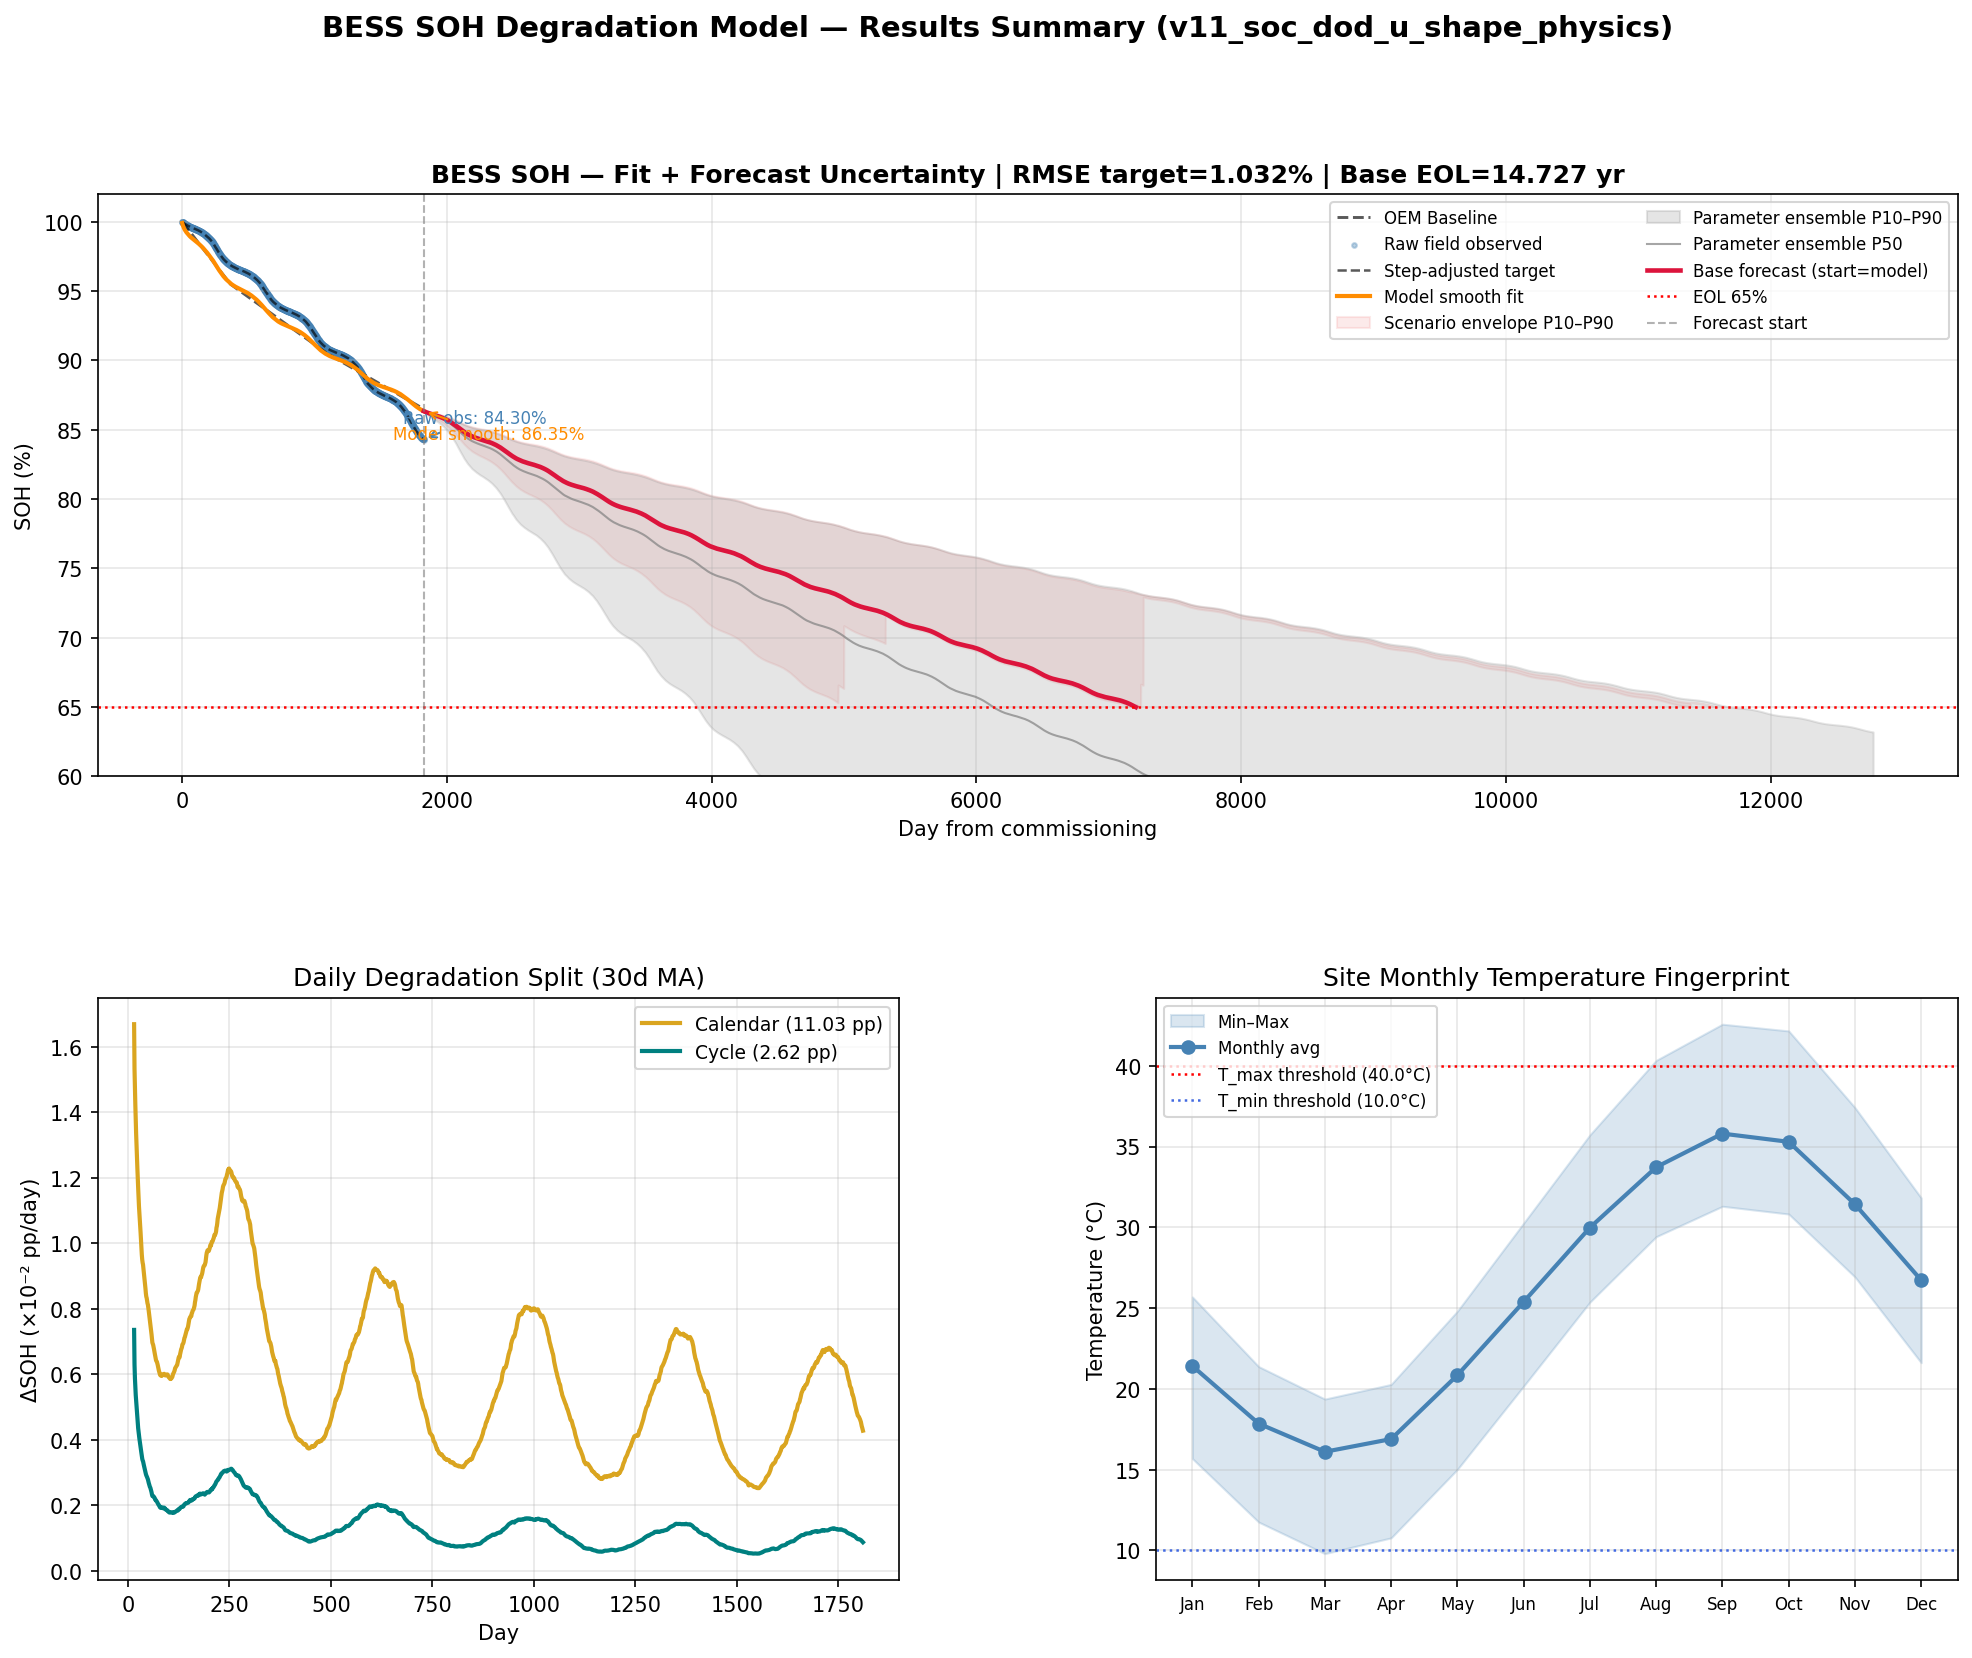


Scenario sensitivity (10 what-if reruns):


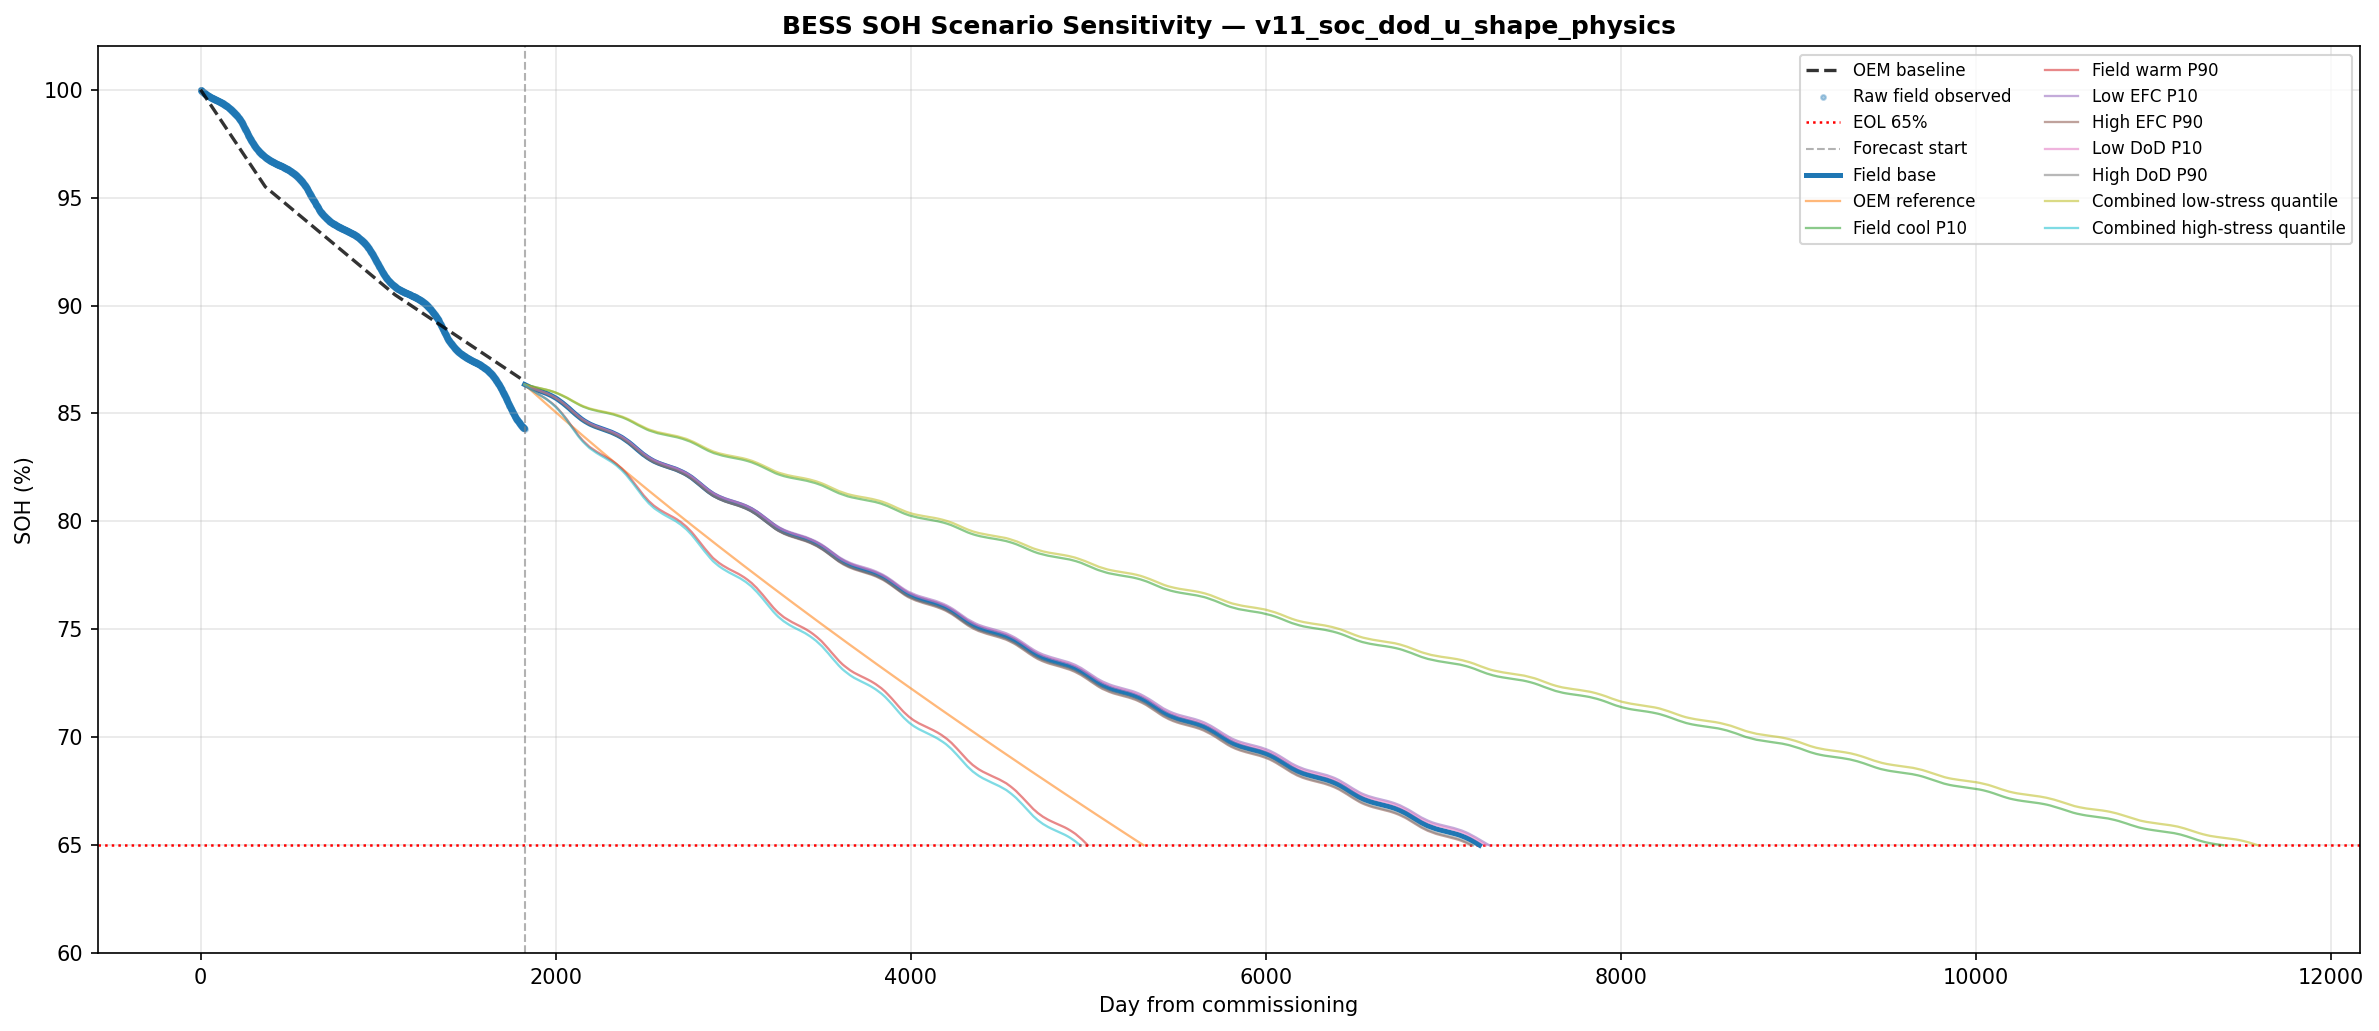


Calibration diagnostics (residuals, stress factors, step events):


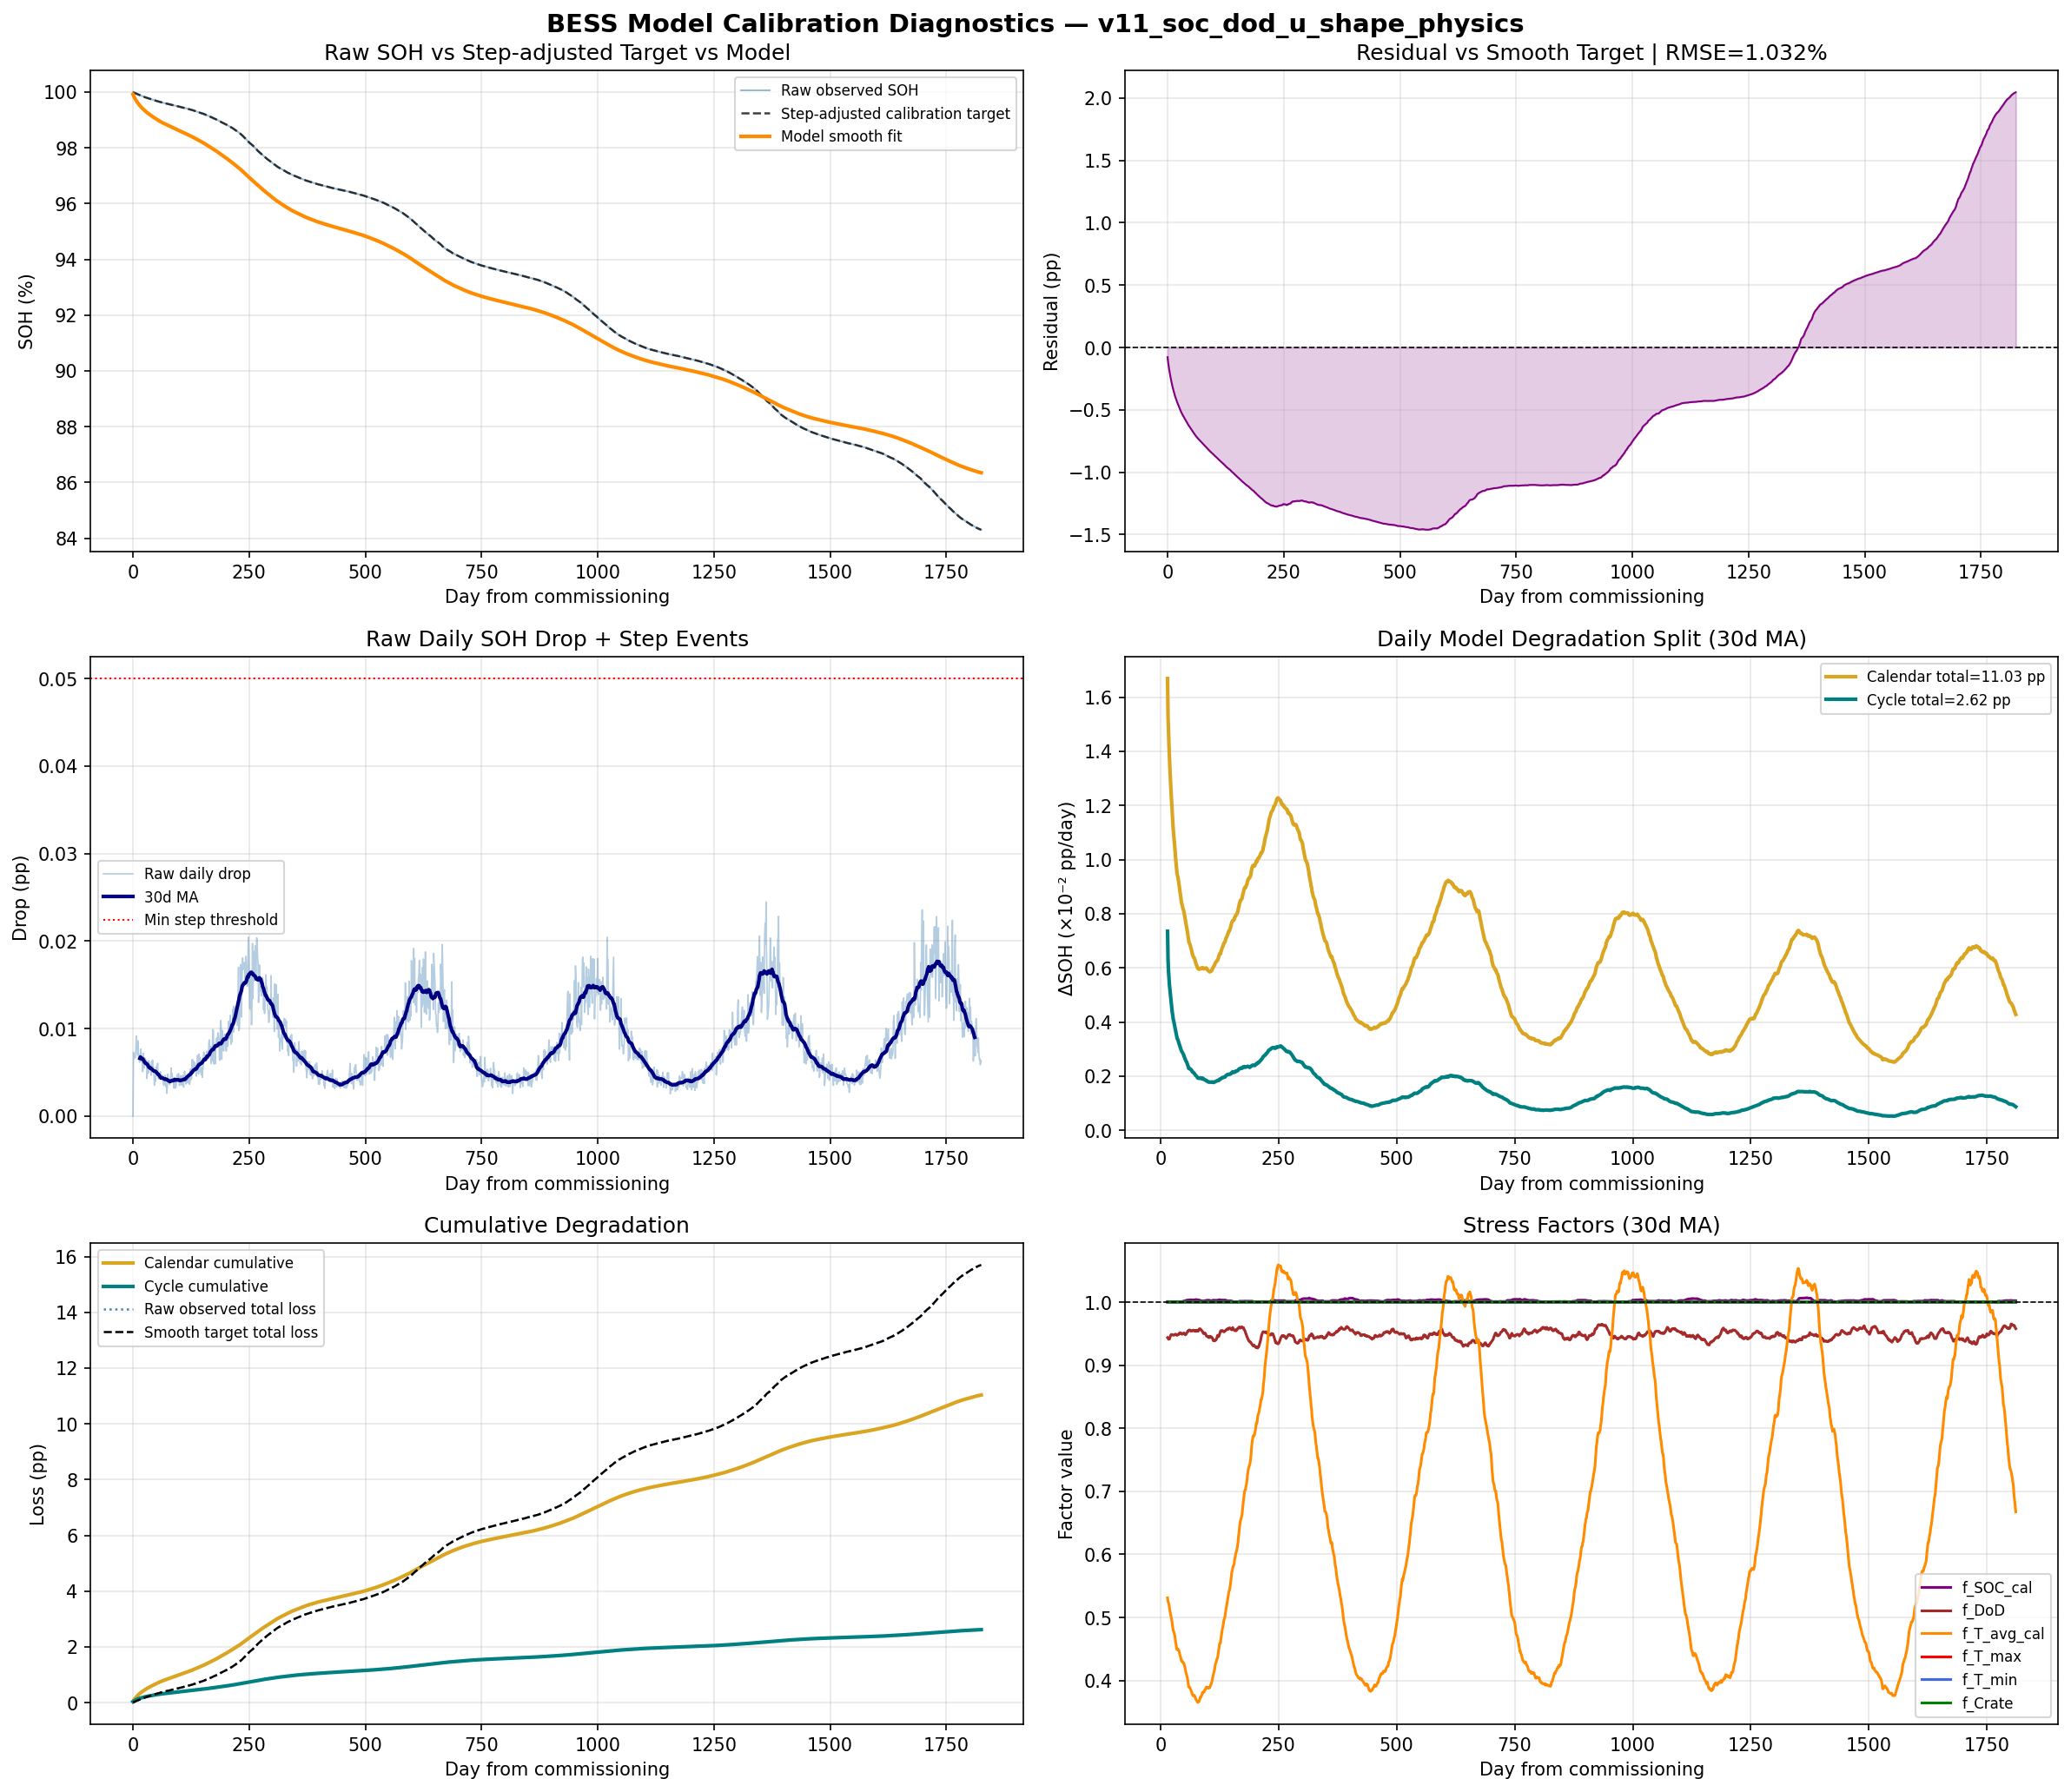

In [18]:
from IPython.display import Image, display

print("Main results (fit + 30-year forecast + uncertainty bands):")
display(Image("bess_soh_results_v11.png"))

print("\nScenario sensitivity (10 what-if reruns):")
display(Image("bess_scenario_sensitivity_v11.png"))

print("\nCalibration diagnostics (residuals, stress factors, step events):")
display(Image("bess_diagnostics_v11.png"))

## Peek at the Excel output's key sheets

`bess_model_results_v11.xlsx` has 7 sheets. Here we load the two most useful
ones for a quick sanity check without leaving the notebook: the calibrated
`Parameters` sheet and the first/last few rows of the `Forecast` sheet.


In [19]:
import pandas as pd

params_sheet = pd.read_excel("bess_model_results_v11.xlsx", sheet_name="Parameters", header=2)
print("Calibrated parameters (first 13 rows):")
display(params_sheet.head(13))

forecast_sheet = pd.read_excel("bess_model_results_v11.xlsx", sheet_name="Forecast")
print("\nForecast — first 3 and last 3 rows:")
display(pd.concat([forecast_sheet.head(3), forecast_sheet.tail(3)]))

Calibrated parameters (first 13 rows):


,Parameter,Value,Lower,Upper,Status,Meaning,Unit/Note
0,A_cal,0.085777,0.00,2.00,OK,Calendar aging coefficient,pp/day^alpha stress-scaled
1,A_cyc,0.051828,0.00,2.00,OK,Cycle aging coefficient,pp/EFC^beta stress-scaled
2,Ea_cal,37300.000022,20000.00,80000.00,OK,Calendar activation energy,J/mol
3,Ea_cyc,31500.000024,15000.00,60000.00,OK,Cycle activation energy,J/mol
4,alpha,0.70117,0.35,0.85,OK,Calendar time exponent,-
5,beta,0.564621,0.35,0.95,OK,Cycle/EFC exponent,-
6,k_SOC_high,0.6,0.00,2.00,OK,Calendar high-SOC penalty coefficient above 75%,-
7,k_SOC_reward,0,0.00,0.40,AT LOWER,Calendar mid-SOC reward coefficient from 45–75%,-
8,k_SOC_low,0.398132,0.00,2.00,OK,Calendar low-SOC penalty coefficient below 45%,-
9,gamma_DoD,1.048013,0.30,2.00,OK,Cycle DoD exponent,-



Forecast — first 3 and last 3 rows:


,Date,Year_from_start,SOH_%,Delta_cal_pp,Delta_cyc_pp,T_avg_C,T_max_C,T_min_C,Avg_SOC_pct,Avg_DoD_pct,EFC_per_day,C_charge_op,C_discharge_op
0,2025-01-01,0.000000,86.341740,0.003646,0.000729,23.6079,27.3087,19.2731,45,95,1.200031,0.237315,0.237484
1,2025-01-02,0.002738,86.337412,0.003606,0.000722,23.3941,28.0466,17.0196,45,95,1.200031,0.237315,0.237484
2,2025-01-03,0.005476,86.333674,0.003103,0.000636,20.4809,24.6881,16.2739,45,95,1.200031,0.237315,0.237484
5377,2039-09-22,14.721424,65.010440,0.004154,0.000633,34.6095,40.4823,29.6095,45,95,1.200031,0.237315,0.237484
5378,2039-09-23,14.724162,65.005096,0.004647,0.000696,37.0000,43.8262,33.0230,45,95,1.200031,0.237315,0.237484
5379,2039-09-24,14.726899,64.999838,0.004571,0.000686,36.6484,43.8285,34.1015,45,95,1.200031,0.237315,0.237484


---
## Notes for your presentation

- Change `SOURCE_FIELD_FILE` above and re-run the "RUN THE MODEL" cells to
  compare best/middle/worst case scenarios — the console output and all
  three charts will regenerate for whichever file you point it at.
- Watch the `[data_consistency_audit_v11]` block near the top of the printed
  output — a score below 80 means the model itself flags that scenario's
  field-vs-OEM relationship as needing a documented explanation before you
  trust its long-term forecast (this happens with the "best case" file).
- The `[guarded_ml_residual]` block tells you whether the optional
  machine-learning correction passed its own validation gate. It is only
  ever applied to the forecast if `ENABLE_ML_RESIDUAL_FORECAST_CORRECTION`
  (Section 1, "v10 guarded residual-correction controls") is manually set to
  `True` *and* the gate passes.
